In [24]:
import os
import pandas as pd
import numpy as np
import re 
import matplotlib.pyplot as plt
import seaborn as sns
import calendar
from datetime import datetime, timedelta
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colors import ListedColormap
import geopandas as gpd
from shapely.validation import make_valid

# --- Configuration ---
path_to_scenarios   = '/home/abhis/india_power/scenarios'
path_to_save_images = '/home/abhis/india_power/images'
path_to_images = '/home/abhis/india_power/images'
path_to_csvs        = '/home/abhis/india_power/gridpath_india_viz/csvs'
# scenario_names = ['iced_2050_cc_1','iced_2050_cc_2','iced_2050_cc_3'] # Example: Explicit list
# scenario_names = ['pier_mid_ra_2040_1','pier_mid_ra_2040_2','pier_mid_ra_2040_3'] # Example: Explicit list
path_to_data = '/home/abhis/india_power/gridpath_india_viz/data/'
tech_labels_ = pd.read_csv(path_to_csvs + '/technology_labels.csv') 
# scenarios_   = pd.read_csv(path_to_csvs + '/ra-scenario_labels.csv')
scenarios_   = pd.read_csv(path_to_csvs + '/ra-new_credits-noprm_noccap.csv')
# scenarios_   = pd.read_csv(path_to_csvs + '/ra-new_credits-noprm_noccap_12_subprob.csv')

# Load and processing system load timepoints

In [2]:
# Load and processing system load timepoints
def _processing_system_load_timepoints(scenarios_):

    dfs_ = []
    for scenario, path_to_scenarios in zip(scenarios_['scenario'], scenarios_['path']):
        path_to_scenario = os.path.join(path_to_scenarios, scenario)

        for dirpath, dirnames, filenames in os.walk(path_to_scenario):
            # Processing scenarios results folder only
            if dirpath.split('/')[-1] == 'results':
                print(scenario)

                df_ = pd.read_csv(os.path.join(dirpath, 'system_load_zone_timepoint.csv'), low_memory = False)
                
                df_ = df_[['timepoint', 
                           'load_zone', 
                           'static_load_mw',
                           'net_imports_mw', 
                           'overgeneration_mw', 
                           'unserved_energy_mw']]
                
                df_ = df_.groupby(['timepoint',
                                   'load_zone']).agg({'static_load_mw': 'sum',
                                                      'net_imports_mw': 'sum',
                                                      'overgeneration_mw': 'sum',
                                                      'unserved_energy_mw': 'sum'}).reset_index(drop = False)
                
                df_ = df_.rename(columns = {'static_load_mw': 'static_load',
                                            'net_imports_mw': 'net_imports',
                                            'overgeneration_mw': 'overgeneration',
                                            'unserved_energy_mw': 'unserved_energy'})
                
                # df_ = pd.melt(df_, id_vars = ['timepoint', 
                #                                'load_zone'], 
                #                 value_vars = ['static_load', 
                #                               'net_imports',
                #                               'overgeneration',
                #                               'unserved_energy'], 
                #                 var_name   = 'technology', 
                #                 value_name = 'power_mw')
                
                # Add iteration descriptors to dataframe
                df_['W'] = dirpath.split('/')[-4].split('_')[-1]
                df_['H'] = dirpath.split('/')[-3].split('_')[-1]
                df_['A'] = dirpath.split('/')[-2].split('_')[-1]
                
                dfs_.append(df_)

    return pd.concat(dfs_).reset_index(drop = True)

df_load_ = _processing_system_load_timepoints(scenarios_)
print(df_load_.head())

pier_no_prm_no_ccap_2040_1
pier_no_prm_no_ccap_2040_2
pier_no_prm_no_ccap_2040_3
pier_no_prm_no_ccap_2040_4
pier_no_prm_no_ccap_2040_5
pier_no_prm_no_ccap_2040_6
pier_no_prm_no_ccap_2040_7
pier_no_prm_no_ccap_2040_8
pier_no_prm_no_ccap_2040_9
pier_no_prm_no_ccap_2040_10
pier_no_prm_no_ccap_2040_11
pier_no_prm_no_ccap_2040_12
pier_no_prm_no_ccap_2040_13
pier_no_prm_no_ccap_2040_14
pier_no_prm_no_ccap_2040_15
pier_no_prm_no_ccap_2040_16
pier_no_prm_no_ccap_2040_17
pier_no_prm_no_ccap_2040_18
    timepoint          load_zone   static_load   net_imports  overgeneration  \
0  2040040101     Andhra_Pradesh  18479.474483 -13241.268286             0.0   
1  2040040101  Arunachal_Pradesh    329.816680    261.713331             0.0   
2  2040040101              Assam   4089.792284   2952.740137             0.0   
3  2040040101             Bhutan      0.000000  -3060.159527             0.0   
4  2040040101              Bihar   9839.340580   6533.758546             0.0   

   unserved_energy  W  H

In [3]:
# Create a timestamp column from 'timepoint' field (YYYYMMDDHH)
tp = df_load_['timepoint'].astype(str)
dates = tp.str[:8]
hours = tp.str[8:].astype(int)  #1-24

df_load_['timestamp'] = (
    pd.to_datetime(dates, format='%Y%m%d')
    + pd.to_timedelta(hours, unit='h')
)
# Reorder so timestamp is first
cols = df_load_.columns.tolist()
cols.insert(0, cols.pop(cols.index('timestamp')))
df_load_ = df_load_[cols]

# State-level metrics for all interations (includes national metrics)

In [28]:
df = df_load_.copy()

# Exclude Bhutan
df = df[df['load_zone'] != "Bhutan"].copy()

HOURS_PER_YEAR = 8760.0  
tau = 1.0  # 1 MW threshold for LOL event

df['is_lol']     = df['unserved_energy'] > tau
df['date']       = df['timestamp'].dt.date
df['hrs_in_tmp'] = 1

def compute_metrics(sub, label):
    """Compute RA metrics for a given dataframe slice."""
    num_iters = sub[['W','H','A']].drop_duplicates().shape[0]
    hrs_run_total = float(sub['hrs_in_tmp'].sum())
    n_years = hrs_run_total / HOURS_PER_YEAR if hrs_run_total else np.nan

    total_lol_hours    = int(sub['is_lol'].sum())
    total_unserved_MWh = float((sub['unserved_energy'] * sub['hrs_in_tmp']).sum())
    total_energy_MWh   = float((sub['static_load']     * sub['hrs_in_tmp']).sum())

    days_with_lol = int(
        sub.groupby(['W','H','A','date'])['is_lol'].max().sum()
    )

    # Annualized metrics
    EUE_MWh_per_yr   = (total_unserved_MWh / n_years) if np.isfinite(n_years) else np.nan
    LOLH_hrs_per_yr  = (total_lol_hours / n_years) if np.isfinite(n_years) else np.nan
    LOLE_days_per_yr = (days_with_lol / n_years) if np.isfinite(n_years) else np.nan

    return {
        'load_zone':               label,
        'iterations (W,H,A)':      num_iters,
        'LOLH (hrs/yr)':           LOLH_hrs_per_yr,
        'EUE (MWh/yr)':            EUE_MWh_per_yr,
        'LOLE (days/yr)':          LOLE_days_per_yr,
        'LOLE (days/10yr)':        (LOLE_days_per_yr * 10) if np.isfinite(LOLE_days_per_yr) else np.nan,
        'LOLP (fraction of hrs)':  (total_lol_hours / hrs_run_total) if hrs_run_total > 0 else np.nan,
        'LOLP (%)':                ((total_lol_hours / hrs_run_total) * 100) if hrs_run_total > 0 else np.nan,
        'Annual Energy (MWh/yr)':  (total_energy_MWh / n_years) if np.isfinite(n_years) else np.nan,
        'NENS (%)':                (100 * EUE_MWh_per_yr / (total_energy_MWh / n_years))
                                   if (n_years and total_energy_MWh > 0) else np.nan,
    }

# --- per-zone metrics ---
zone_metrics = []
for zone, sub in df.groupby("load_zone"):
    zone_metrics.append(compute_metrics(sub.copy(), zone))
metrics_df = pd.DataFrame(zone_metrics)

# --- national metric (all zones pooled) ---
national_metric_df = pd.DataFrame([
    compute_metrics(df.copy(), "National (excl. Bhutan)")
])

# --- outputs ---
print("=== Per-zone metrics ===")
print(metrics_df)

print("\n=== National metric (excluding Bhutan) ===")
print(national_metric_df)


=== Per-zone metrics ===
             load_zone  iterations (W,H,A)  LOLH (hrs/yr)  EUE (MWh/yr)  \
0       Andhra_Pradesh                  18       0.277778    710.816432   
1    Arunachal_Pradesh                  18       0.000000      0.000000   
2                Assam                  18       0.000000      0.000000   
3                Bihar                  18       0.000000      0.000000   
4           Chandigarh                  18      10.111111    719.669064   
5         Chhattisgarh                  18       0.000000      0.000000   
6   Dadra_Nagar_Haveli                  18      51.666667  33131.259502   
7            Daman_Diu                  18       6.333333   2508.571033   
8                Delhi                  18       6.777778  28842.532303   
9                  Goa                  18       7.500000   5367.463507   
10             Gujarat                  18       6.944444  28757.033119   
11             Haryana                  18       0.000000      0.000000   


# States violating the global standards

In [30]:
# Filter zones with LOLP > 0.0274 OR LOLE > 1 day/10yr
filtered_metrics_global_df = metrics_df[
    (metrics_df['LOLP (%)'] > 0.0274) |
    (metrics_df['LOLE (days/10yr)'] > 1.0)
].reset_index(drop=True)

print("=== Zones with inadequate reliability ===")
print(filtered_metrics_global_df)


=== Zones with inadequate reliability ===
             load_zone  iterations (W,H,A)  LOLH (hrs/yr)  EUE (MWh/yr)  \
0       Andhra_Pradesh                  18       0.277778    710.816432   
1           Chandigarh                  18      10.111111    719.669064   
2   Dadra_Nagar_Haveli                  18      51.666667  33131.259502   
3            Daman_Diu                  18       6.333333   2508.571033   
4                Delhi                  18       6.777778  28842.532303   
5                  Goa                  18       7.500000   5367.463507   
6              Gujarat                  18       6.944444  28757.033119   
7        Jammu_Kashmir                  18       1.500000   2307.237774   
8            Karnataka                  18       0.944444  16080.888895   
9          Maharashtra                  18       0.722222   8956.987800   
10           Meghalaya                  18       0.944444    268.038060   
11            Nagaland                  18       0.611111 

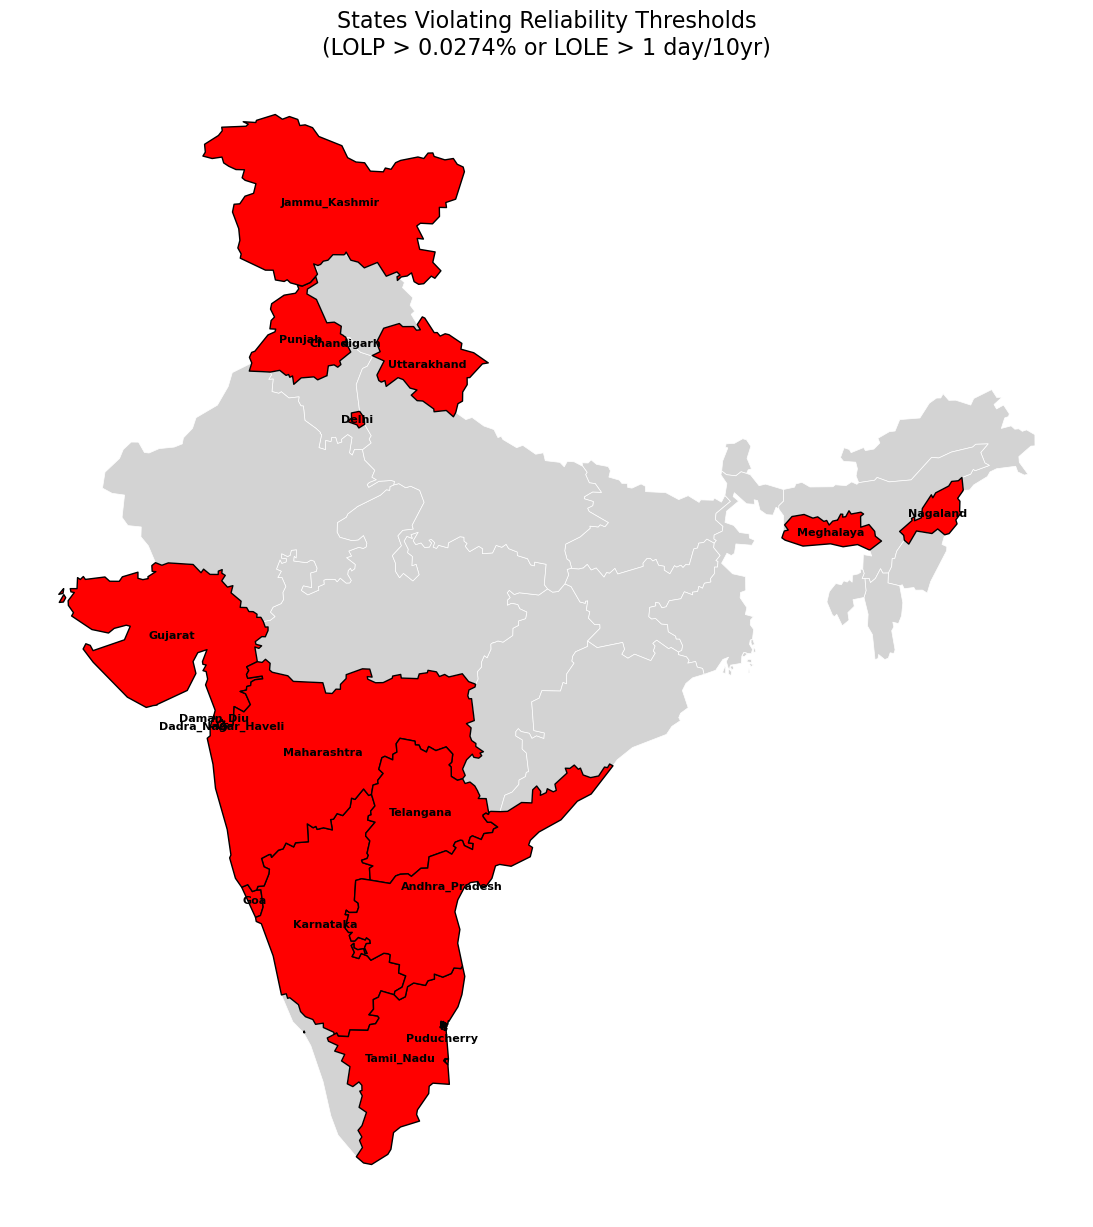

In [ ]:
# --- Load shapefile ---
_india = gpd.read_file(path_to_data + r"map/india/india-polygon.shp").to_crs("epsg:4326")
_india['geometry'] = _india['geometry'].apply(lambda geom: make_valid(geom) if geom else None)
_india = _india.dropna(subset=['geometry'])

# Harmonize naming
_india = _india.rename(columns={'st_nm': 'load_zone'})
_india['load_zone'] = _india['load_zone'].str.replace(" ", "_").str.replace("_and_", "_")

# Fix union and drop duplicates (as in your workflow)
_india.loc[35, 'geometry'] = _india.loc[35, 'geometry'].union(_india.loc[36, 'geometry'])
_india = _india.drop([0,36]).reset_index(drop=True)

# --- Merge with metrics ---
_india = pd.merge(_india, metrics_df, on='load_zone')

# --- Flag violating states ---
_india['violation'] = (
    (_india['LOLP (%)'] > 0.0274) |
    (_india['LOLE (days/10yr)'] > 1.0)
)

# --- Plot ---
fig, ax = plt.subplots(figsize=(14,15))

# All states light grey
_india.plot(ax=ax, color="lightgrey", edgecolor="white", lw=0.5, zorder=1)

# Violating states red with black border
_india[_india['violation']].plot(
    ax=ax, color="red", edgecolor="black", lw=1.0, zorder=2
)

# Labels for violating states
for _, row in _india[_india['violation']].iterrows():
    x, y = row['geometry'].centroid.x, row['geometry'].centroid.y
    ax.text(x, y, row['load_zone'], fontsize=8, ha='center', va='center',
            color='black', weight='bold', zorder=3)

# Title & cleanup
ax.set_title("States Violating Reliability Thresholds\n(LOLP > 0.0274% or LOLE > 1 day/10yr)",
             fontsize=16)
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

plt.show()


# States violating the CEA Standards

In [22]:
# Filter zones with LOLP > 0.2 OR NENS > 0.05
filtered_metrics_cea_df = metrics_df[
    (metrics_df['LOLP (fraction of hrs)'] > 0.2) |
    (metrics_df['NENS (%)'] > 0.05)
].reset_index(drop=True)

print("=== Zones with LOLP > 0.2 or NENS > 0.05 ===")
print(filtered_metrics_cea_df)


=== Zones with LOLP > 0.2 or NENS > 0.05 ===
            load_zone  iterations (W,H,A)  LOLH (hrs/yr)  EUE (MWh/yr)  \
0  Dadra_Nagar_Haveli                  18      51.666667  33131.259502   

   LOLE (days/yr)  LOLE (days/10yr)  LOLP (fraction of hrs)  LOLP (%)  \
0       23.666667        236.666667                0.005898  0.589802   

   Annual Energy (MWh/yr)  NENS (%)  
0            2.409489e+07  0.137503  


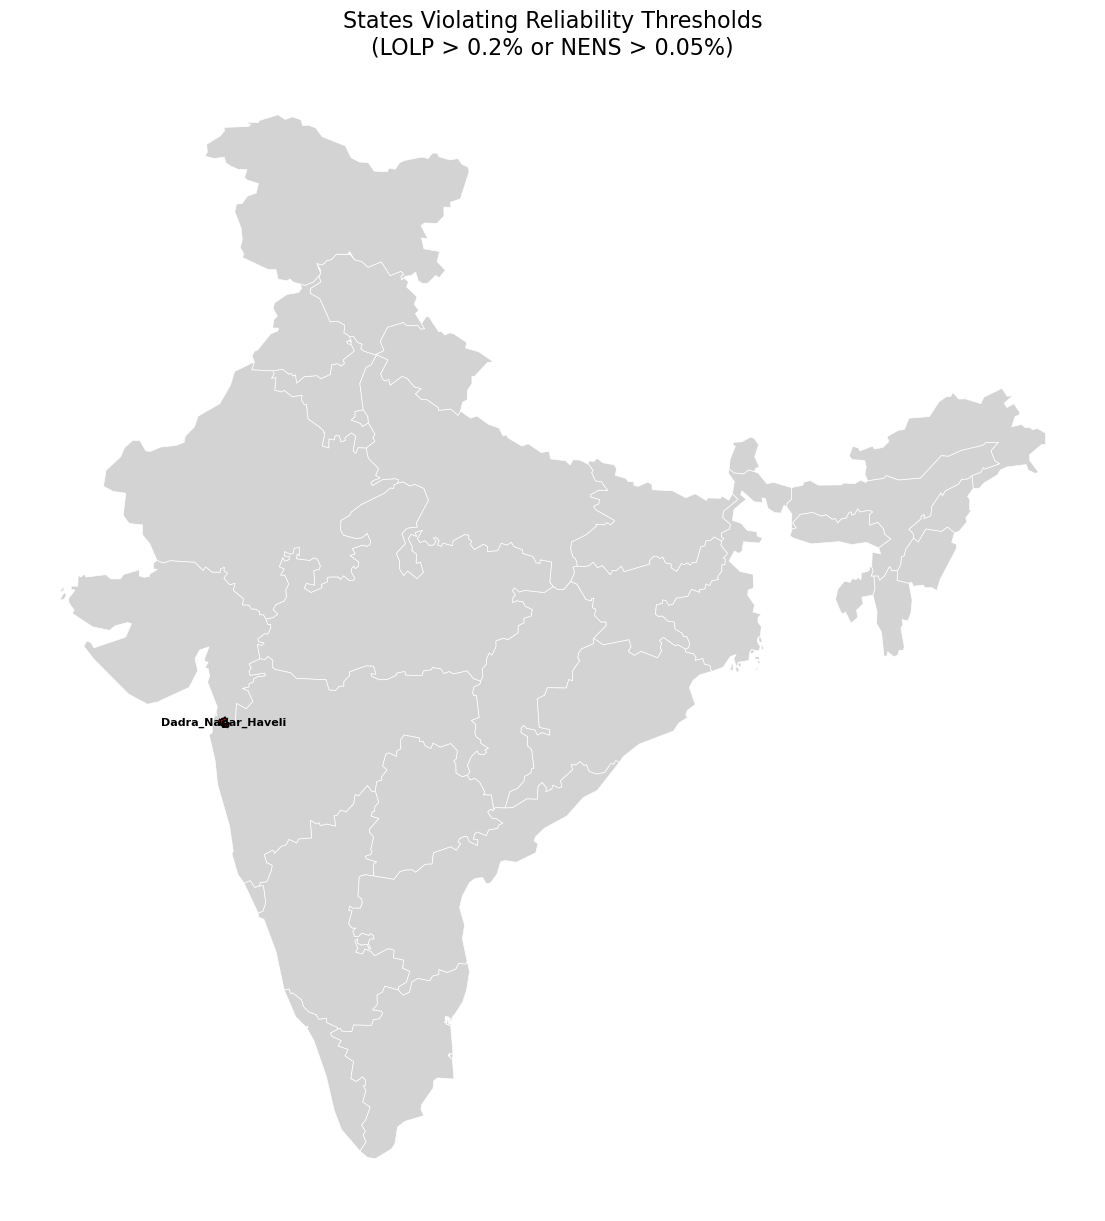

In [35]:
# --- Load shapefile ---
_india = gpd.read_file(path_to_data + r"map/india/india-polygon.shp").to_crs("epsg:4326")
_india['geometry'] = _india['geometry'].apply(lambda geom: make_valid(geom) if geom else None)
_india = _india.dropna(subset=['geometry'])

# Harmonize naming
_india = _india.rename(columns={'st_nm': 'load_zone'})
_india['load_zone'] = _india['load_zone'].str.replace(" ", "_").str.replace("_and_", "_")

# Fix union and drop duplicates (as in your workflow)
_india.loc[35, 'geometry'] = _india.loc[35, 'geometry'].union(_india.loc[36, 'geometry'])
_india = _india.drop([0,36]).reset_index(drop=True)

# --- Merge with metrics ---
_india = pd.merge(_india, metrics_df, on='load_zone')

# --- Flag violating states (LOLP > 0.2% OR NENS > 0.05%) ---
_india['violation'] = (
    (_india['LOLP (%)'] > 0.2) |   # LOLP is already in %
    (_india['NENS (%)'] > 0.05)    # NENS is also in %
)

# --- Plot ---
fig, ax = plt.subplots(figsize=(14,15))

# All states light grey
_india.plot(ax=ax, color="lightgrey", edgecolor="white", lw=0.5, zorder=1)

# Violating states red with black border
_india[_india['violation']].plot(
    ax=ax, color="red", edgecolor="black", lw=1.0, zorder=2
)

# Labels for violating states
for _, row in _india[_india['violation']].iterrows():
    x, y = row['geometry'].centroid.x, row['geometry'].centroid.y
    ax.text(x, y, row['load_zone'], fontsize=8, ha='center', va='center',
            color='black', weight='bold', zorder=3)

# Title & cleanup
ax.set_title("States Violating Reliability Thresholds\n(LOLP > 0.2% or NENS > 0.05%)",
             fontsize=16)
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

plt.show()


# Reliability Assesment

## Processing state-level metrics for every interation (W, H, and A combinations)

In [36]:
df = df_load_.copy()

# --- flags & helpers ---
df['is_lol']     = df['unserved_energy'] > tau # 1MW threshold for LOL event
df['date']       = df['timestamp'].dt.date
df['hrs_in_tmp'] = 1

metrics, events_stats = [], []
group_cols = ['load_zone', 'W', 'H', 'A']
HOURS_PER_YEAR = 8760.0  

for (zone, w, h, a), sub in df.groupby(group_cols):
    hrs_run = sub['hrs_in_tmp'].sum()
    n_years = hrs_run / HOURS_PER_YEAR if hrs_run > 0 else np.nan

    # --- energy & tallies (MW → MWh by multiplying hrs_in_tmp) ---
    total_lol_hours   = int(sub['is_lol'].sum())
    total_unserved_MWh = float((sub['unserved_energy'] * sub['hrs_in_tmp']).sum())
    total_energy_MWh   = float((sub['static_load']     * sub['hrs_in_tmp']).sum())
    days_with_lol      = int(sub.groupby('date')['is_lol'].max().sum())

    # --- annualized metrics ---
    LOLH   = total_lol_hours / n_years if np.isfinite(n_years) else np.nan
    EUE_MWh = total_unserved_MWh / n_years if np.isfinite(n_years) else np.nan
    EUE_GWh = EUE_MWh / 1000 if np.isfinite(EUE_MWh) else np.nan
    LOLE_10yr = (days_with_lol / n_years * 10) if np.isfinite(n_years) else np.nan
    LOLP   = total_lol_hours / hrs_run if hrs_run > 0 else np.nan
    annual_energy = total_energy_MWh / n_years if np.isfinite(n_years) else np.nan
    NENS   = 100 * EUE_MWh / annual_energy if (annual_energy and np.isfinite(annual_energy)) else np.nan

    metrics.append({
        'load_zone':        zone,
        'W':                w, 'H': h, 'A': a,
        'LOLH (hrs/yr)':    LOLH,
        'EUE (GWh/yr)':     EUE_GWh,
        'LOLE (days/10yr)': LOLE_10yr,
        'LOLP (fraction)':  LOLP,
        'NENS (%)':         NENS
    })

    # --- event‐level stats ---
    run = sub.sort_values('timestamp').copy()
    run['event_start'] = (~run['is_lol'].shift(fill_value=False)) & run['is_lol']
    run['event_id']    = run['event_start'].cumsum()

    durations = run[run['is_lol']].groupby('event_id').size()
    events_stats.append({
        'load_zone':              zone,
        'W': w, 'H': h, 'A': a,
        'num_LOL_events':         int(durations.count()),
        'total_LOL_duration_hrs': int(durations.sum())
    })

# Build DataFrames
metrics_per_zone_df = pd.DataFrame(metrics)
lol_events_df       = pd.DataFrame(events_stats)


print(lol_events_df)


          load_zone   W   H   A  num_LOL_events  total_LOL_duration_hrs
0    Andhra_Pradesh   1   1   1               0                       0
1    Andhra_Pradesh  10  10  10               0                       0
2    Andhra_Pradesh  11  11  11               0                       0
3    Andhra_Pradesh  12  12  12               0                       0
4    Andhra_Pradesh  13  13  13               0                       0
..              ...  ..  ..  ..             ...                     ...
625     West_Bengal   5   5   5               0                       0
626     West_Bengal   6   6   6               0                       0
627     West_Bengal   7   7   7               0                       0
628     West_Bengal   8   8   8               0                       0
629     West_Bengal   9   9   9               0                       0

[630 rows x 6 columns]


## State-level metric scatter plots

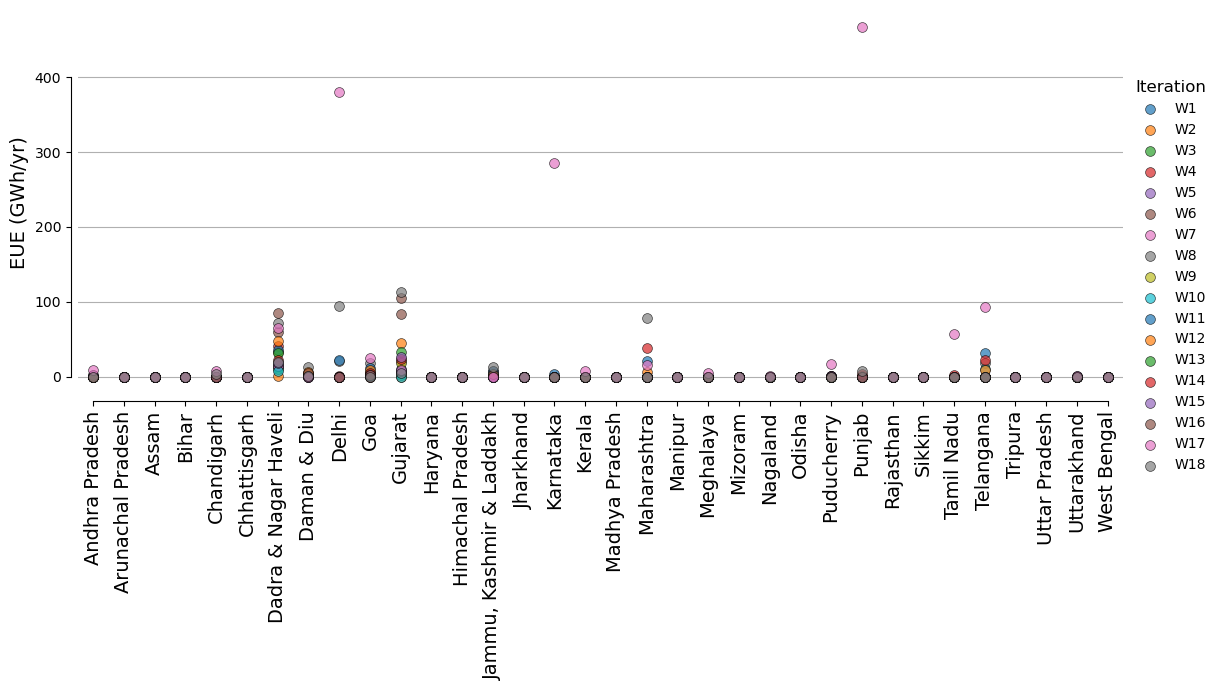

In [12]:
def plot_metrics(ax, df, metric, group_cols = ('W')): 
    
    # 1) remove Bhutan entirely
    df = df[df['load_zone'] != 'Bhutan'].copy()

    # 2) define mapping for special zones
    display_map = {'Jammu_Kashmir': 'Jammu, Kashmir & Laddakh',
                   'Dadra_Nagar_Haveli': 'Dadra & Nagar Haveli',
                   'Daman_Diu': 'Daman & Diu'}

    # 3) determine unique zones (in order of appearance)
    zones = df['load_zone'].unique()
    zone_pos = {zone: idx for idx, zone in enumerate(zones)}

    # 4) build list of display labels in the same order
    zone_labels = [display_map.get(z, z.replace('_', ' ')) for z in zones]

    grouped_data_iterable = df.groupby(list(group_cols))
    
    # Define a key for sorting the groups to ensure W1, W2, ..., W10 sequence
    def sort_key_for_groups(group_item):
        group_key = group_item[0]  # This is 'vals' from groupby
        
        if not group_cols: # Should not happen if group_cols has a default
            return group_key

        # Handle single grouping column (vals is scalar)
        if not isinstance(group_key, tuple):
            if group_cols[0] == 'W':  # Sort numerically if 'W'
                try:
                    return int(group_key)
                except ValueError:
                    return group_key  # Fallback to string sort
            return group_key
        # Handle multiple grouping columns (vals is a tuple)
        else:
            if group_cols[0] == 'W': # Sort by 'W' numerically first
                try:
                    # Create a sort key: (int(W_val), other_vals...)
                    return (int(group_key[0]),) + group_key[1:]
                except (ValueError, TypeError):
                    return group_key  # Fallback
            return group_key # Default tuple sort

    sorted_groups = []
    if group_cols:
        try:
            sorted_groups = sorted(list(grouped_data_iterable), key=sort_key_for_groups)
        except Exception: # Fallback in case of unexpected error during sorting
            sorted_groups = list(grouped_data_iterable)
    else:
        sorted_groups = list(grouped_data_iterable)


    for vals, grp in sorted_groups:  # Iterate over sorted groups
        # Corrected label generation
        current_label = ""
        if isinstance(vals, tuple):  # Multiple grouping columns
            label_parts = []
            for i, col_name in enumerate(group_cols):
                label_parts.append(f"{col_name}{vals[i]}")
            current_label = "-".join(label_parts)
        else:  # Single grouping column
            current_label = f"{group_cols[0]}{vals}"
        
        x = grp['load_zone'].map(zone_pos)
        y = grp[metric]
        
        ax.scatter(x, y, 
                   label      = current_label, 
                   s          = 50, 
                   alpha      = 0.7, 
                   edgecolors = 'black', 
                   lw         = .5, 
                   zorder     = 10)

    # set the custom ticks & labels
    ax.set_xticks(list(zone_pos.values()))

    ax.set_ylabel(metric, fontsize = 14)

    # Add a legend
    ax.legend(
        title='Iteration',
        bbox_to_anchor=(1., .85), # Position legend outside
        loc='upper left',
        fontsize=10,
        title_fontsize=12, frameon=False,
    )
    
    # Add Y-axis gridlines only
    #ax.grid(True, axis='y', linestyle='--', alpha=1.0, linewidth=1.0, zorder=1)
    ax.grid(axis = 'y')

    sns.despine(offset=5, trim=True)
    ax.set_xlim(-.5, len(list(zone_pos.values())) - .5)

    ax.set_xticklabels(zone_labels, 
                       rotation=90, 
                       ha='center', 
                       fontsize=14) 
      

# fig, ax = plt.subplots(figsize = (14, 7))
# plot_metrics(ax, metrics_per_zone_df, metric = 'LOLH (hrs/yr)')
# # Ensure tight_layout is called after all elements are added for proper spacing
# plt.tight_layout(rect=[0, 0, 0.88, 1]) # Adjusted rect slightly for legend
# plt.show()

fig, ax = plt.subplots(figsize = (14, 7))
plot_metrics(ax, metrics_per_zone_df, metric = 'EUE (GWh/yr)')
# Ensure tight_layout is called after all elements are added for proper spacing
plt.tight_layout(rect = [0, 0, 0.88, 1]) # Adjusted rect slightly for legend
plt.show()

# fig, ax = plt.subplots(figsize = (14, 7))
# plot_metrics(ax, metrics_per_zone_df, metric = 'NENS (%)')
# # Ensure tight_layout is called after all elements are added for proper spacing
# plt.tight_layout(rect=[0, 0, 0.88, 1]) # Adjusted rect slightly for legend
# plt.show()

# fig, ax = plt.subplots(figsize = (14, 7))
# plot_metrics(ax, lol_events_df, metric = 'num_LOL_events')
# # Ensure tight_layout is called after all elements are added for proper spacing
# plt.tight_layout(rect=[0, 0, 0.88, 1]) # Adjusted rect slightly for legend
# plt.show()


### Alternative version with non-zero sample only

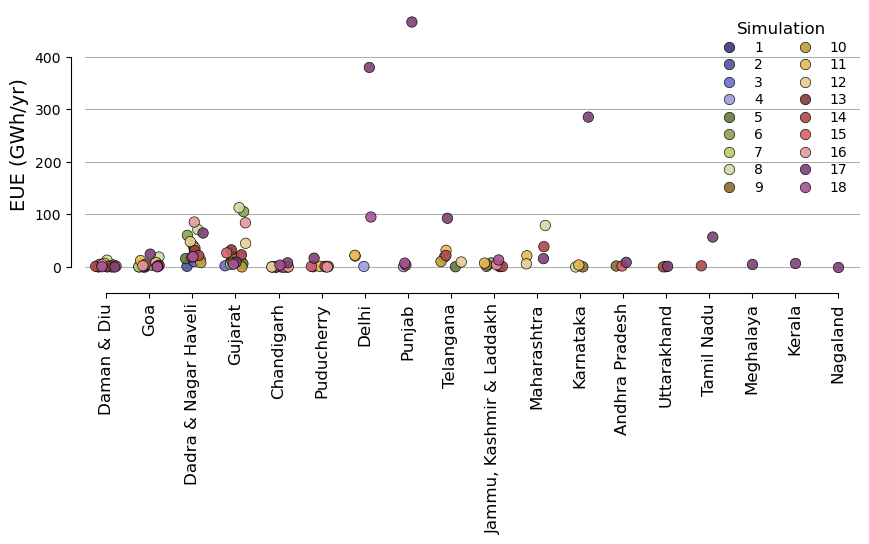

In [14]:
def plot_metrics(ax, df, metric, group_cols = ('W')): 
    
    # 1) remove Bhutan entirely
    df = df[df['load_zone'] != 'Bhutan'].copy()
    df = df.loc[df[metric] > 0.] 

    # 2) define mapping for special zones
    display_map = {'Jammu_Kashmir': 'Jammu, Kashmir & Laddakh',
                   'Dadra_Nagar_Haveli': 'Dadra & Nagar Haveli',
                   'Daman_Diu': 'Daman & Diu'}

    # 3) determine unique zones (in order of appearance)
    zones    = df['load_zone'].unique()
    zone_pos = {zone: idx for idx, zone in enumerate(zones)}

    
    # 4) build list of display labels in the same order
    zone_labels = [display_map.get(z, z.replace('_', ' ')) for z in zones]

    x_ = np.arange(zones.shape[0])

    # for x, zone in zip(x_, zones):
    #     y = df.loc[df['load_zone'] == zone, metric].to_numpy()
    #     print(y.shape)


    ax.set_xticks(x_, list(zone_pos.values()))

    sns.stripplot(data      = df,
                  x         = "load_zone",
                  y         = metric, 
                  size      = "s", 
                  hue       = "iteration",
                  s         = 7.5,
                  alpha     = 0.9, 
                  edgecolor = 'k',
                  linewidth        = .5,
                  zorder    = 9, 
                  jitter    = .25,
                  palette   = "tab20b")

    # set the custom ticks & labels

    ax.set_ylabel(metric, fontsize = 14)
    ax.set_xlabel('', fontsize = 14)

    # Add a legend
    ax.legend(
        title = 'Simulation',
        bbox_to_anchor = (1., 1), # Position legend outside
        #loc='upper right',
        fontsize=10, 
        labelspacing = .25,
        title_fontsize=12, 
        frameon=False, ncol = 2)
    
    # Add Y-axis gridlines only
    #ax.grid(True, axis='y', linestyle='--', alpha=1.0, linewidth=1.0, zorder=1)
    ax.grid(axis = 'y')

    sns.despine(offset=10, trim=True)
    ax.set_xlim(-.5, len(list(zone_pos.values())) - .5)
    
    ax.set_xticklabels(zone_labels, 
                       rotation=90, 
                       ha='center', 
                       fontsize=12) 

df = metrics_per_zone_df.copy()
df['iteration'] = df['W']
df['iteration'] = df['iteration'].astype(int)
df              = df.sort_values(by='iteration')
df['iteration'] = df['iteration'].astype(str)

fig, ax = plt.subplots(figsize = (10., 3.5))
plot_metrics(ax, df, metric = 'EUE (GWh/yr)')
# Ensure tight_layout is called after all elements are added for proper spacing
#plt.tight_layout(rect = [0, 0, 0.88, 1]) # Adjusted rect slightly for legend

plt.savefig(path_to_save_images + '/zone-level_EUE.png',
            bbox_inches = 'tight',
            dpi         = 600)

plt.savefig(path_to_save_images + '/zone-level_EUE.pdf',
            bbox_inches = 'tight',
            dpi         = 600)

plt.show()



# Loss-of-load probability heatmap

In [15]:
df = df_load_.copy()

tau = 1.
df['lol'] = df['unserved_energy'] > tau

df = df[['timepoint', 'load_zone', 'lol']]

df = df.groupby(['timepoint', 'load_zone']).agg({'lol': 'sum'}).reset_index(drop = False)
df = df.groupby(['timepoint']).agg({'lol': 'sum'}).reset_index(drop = False)

df['interval'] = df['timepoint'].apply(lambda x: int(str(x)[-2:]))
df['month']    = df['timepoint'].apply(lambda x: int(str(x)[-6:-4]))

df = df[['month', 'interval', 'lol']]
df = df.groupby(['month', 'interval']).agg({'lol': 'sum'}).reset_index(drop = False)
print(df)

months_    = np.array([4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3])
intervals_ = df['interval'].unique()
LOLP_      = np.zeros((months_.shape[0], intervals_.shape[0]))

for m, month in zip(range(months_.shape[0]), months_):
    for interval in intervals_:
        print(df.loc[(df['month'] == month) & (df['interval'] == interval), 'lol'].to_numpy()[0], calendar.monthrange(2001, month)[1])
        LOLP_[m, interval - 1] = df.loc[(df['month'] == month) & (df['interval'] == interval), 'lol'].to_numpy()[0]/(18*calendar.monthrange(2001, month)[1])

print(LOLP_.max(), LOLP_.min())

     month  interval  lol
0        1         1    0
1        1         2    0
2        1         3    0
3        1         4    0
4        1         5    0
..     ...       ...  ...
283     12        20   11
284     12        21    6
285     12        22    4
286     12        23    0
287     12        24    0

[288 rows x 3 columns]
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
0 30
1 30
3 30
7 30
5 30
4 30
3 30
28 30
1 30
1 30
0 30
0 30
0 30
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
1 31
2 31
1 31
1 31
6 31
7 31
4 31
5 31
24 31
0 31
0 31
0 31
0 31
0 31
0 30
0 30
0 30
0 30
1 30
0 30
2 30
3 30
1 30
1 30
1 30
0 30
1 30
2 30
21 30
29 30
12 30
5 30
8 30
0 30
0 30
2 30
0 30
0 30
12 31
12 31
10 31
10 31
11 31
5 31
14 31
6 31
0 31
0 31
2 31
3 31
1 31
3 31
8 31
6 31
1 31
12 31
25 31
13 31
12 31
12 31
10 31
12 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
4 31
16 31
14 31
13 31
17 31
24 31
15 31
4 31
0 31
0 31
0 31
0 31
0 31
0 31
0 31
0 30
1 30
0 30
0 30
1 30
2 30
9 30
11 30

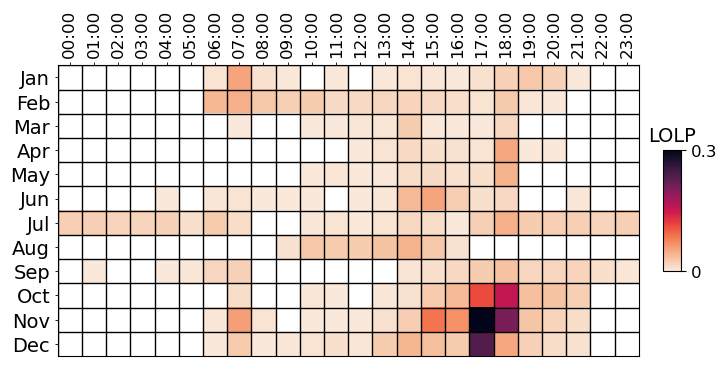

In [16]:

fig, ax = plt.subplots(figsize=(7.5, 7.5))

# --- Put months in calendar order (Jan → Dec) ---
# Your original FY order:
month_fy = ['Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar']
# Indices that map FY order → calendar order
order_to_calendar = [9, 10, 11, 0, 1, 2, 3, 4, 5, 6, 7, 8]
# Calendar labels for y-axis
month_ = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Hour labels
interval_ = [f'{h:02d}:00' for h in np.arange(24, dtype=int)]

# Colormap
_cmap = sns.color_palette("rocket_r", as_cmap=True)

# --- Reindex data rows to match Jan→Dec ---
# Assumes LOLP_ has shape (12, 24) with rows in FY order Apr→Mar
LOLP_plot = LOLP_[order_to_calendar, :].astype(float)

# Optional: hide zeros for plotting (keep them as NaN so they appear blank)
LOLP_plot_masked = LOLP_plot.copy()
LOLP_plot_masked[LOLP_plot_masked == 0.0] = np.nan

# --- Draw heatmap ---
ax.matshow(
    LOLP_plot_masked,
    cmap=_cmap,
    vmin=0.0,
    extent=[0, 24, 12, 0]  # x: 0→24 hours, y: 0→12 rows (top to bottom)
)

# Clear major ticks & labels
ax.set_yticks(range(len(month_)), []*len(month_))
ax.set_xticks(range(len(interval_)), []*len(interval_))

# Add minor ticks with labels centered in each cell
ax.set_yticks(np.arange(len(month_), dtype=int) + 0.5, month_,
              rotation=0, minor=True, size=14)

ax.set_xticks(np.arange(len(interval_), dtype=int) + 0.5, interval_,
              rotation=90, minor=True, size=12)

# Tick styling
ax.tick_params(which='major', bottom=False, left=False, top=False)
ax.tick_params(which='minor', bottom=False, top=True)

# Grid
ax.grid(which='major', color='k', linestyle='-', linewidth=1.0)

# --- Colorbar, normalized to the actual (masked) data range ---
data_max = float(np.nanmax(LOLP_plot)) if np.isfinite(np.nanmax(LOLP_plot)) else 1.0
norm = plt.Normalize(vmin=0.0, vmax=data_max)
sm = cm.ScalarMappable(norm=norm, cmap=_cmap)

cbar = fig.colorbar(
    sm,
    cax=ax.inset_axes([25, 3.5, .75, 5], transform=ax.transData),
    orientation='vertical'
)

cbar.set_ticks([0.0, data_max], labels=['0', f'{np.round(data_max, 2)}'], size=12)
cbar.ax.set_title('LOLP', rotation=0, size=14)

# --- Save & show ---
plt.savefig(path_to_save_images + '/zone-level_LOLP_heatmap.png',
            bbox_inches='tight', dpi=600)
plt.savefig(path_to_save_images + '/zone-level_LOLP_heatmap.pdf',
            bbox_inches='tight', dpi=600)
plt.show()

# Loss-of-load events distribution

In [12]:
df = df_load_.copy()

# This is at the national-level!
df = df.groupby(['timestamp', 'W', 'H', 'A', 'load_zone']).agg({'unserved_energy': 'sum'}).reset_index(drop = False)

df['iteration'] = df['W'] + df['H'] + df['A']
df = df[['iteration', 'timestamp', 'load_zone', 'unserved_energy']]

df = df.sort_values(by = ['iteration', 'timestamp', 'load_zone']).reset_index(drop = True)

# Load shedding greater than 1MW
tau = 1.

df_events_ = []
for load_zone in df['load_zone'].unique():
    print(load_zone)
    for iter in df['iteration'].unique():
        idx_ = (df['iteration'] == iter) & (df['load_zone'] == load_zone)
        if idx_.sum() > 0:
            run                = df.loc[idx_].copy()
            run['is_lol']      = run['unserved_energy'] > tau
            run['event_start'] = (~run['is_lol'].shift(fill_value=False)) & run['is_lol']
            run['event_id']    = run['event_start'].cumsum()
            #print(load_zone, iter, (run['unserved_energy'] > 0).sum(), run['is_lol'].sum())

            df_event_              = pd.DataFrame(columns = ['hours', 'load_zone', 'iteration'])
            df_event_['hours']     = run[run['is_lol']].groupby('event_id').size().to_numpy()
            df_event_['load_zone'] = load_zone
            df_event_['iteration'] = iter

            df_events_.append(df_event_)

df_events_ = pd.concat(df_events_, axis = 0).reset_index(drop = True)
print(df_events_.head())

Andhra_Pradesh
Arunachal_Pradesh
Assam
Bhutan
Bihar
Chandigarh
Chhattisgarh
Dadra_Nagar_Haveli
Daman_Diu
Delhi
Goa
Gujarat
Haryana
Himachal_Pradesh
Jammu_Kashmir
Jharkhand
Karnataka
Kerala
Madhya_Pradesh
Maharashtra
Manipur
Meghalaya
Mizoram
Nagaland
Odisha
Puducherry
Punjab
Rajasthan
Sikkim
Tamil_Nadu
Telangana
Tripura
Uttar_Pradesh
Uttarakhand
West_Bengal
   hours       load_zone iteration
0      1  Andhra_Pradesh    151515
1      3  Andhra_Pradesh    171717
2      1  Andhra_Pradesh       999
3      1      Chandigarh    101010
4      2      Chandigarh       111


[ 1  3  2  5  7  8  6  4  9 12 10 13 15] 1833
[602. 200.  67.  32.  28.  20.  14.   5.   2.   2.   0.   1.   3.   1.]
[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15.]
(14,) (15,)


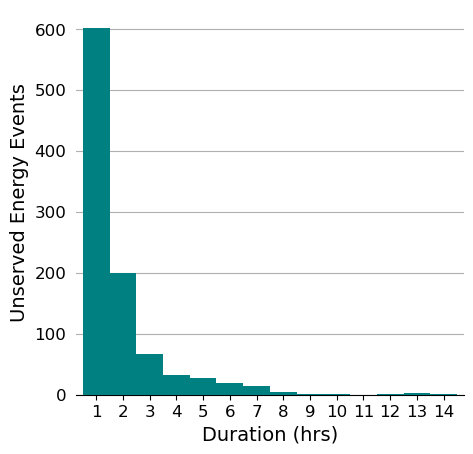

In [13]:
def _plot_LOLE_distribution(ax, df_events_):
    print(df_events_['hours'].unique(), df_events_['hours'].sum())

    (n, bins, patches) = ax.hist(df_events_['hours'], bins = 14, range = (1, 15), zorder = 5, color = 'teal')
    print(n)
    print(bins)
    print(n.shape, bins.shape)

    ax.set_xlabel('Duration (hrs)', fontsize = 14)
    ax.set_ylabel('Unserved Energy Events', fontsize = 14)
    ax.set_xticks(np.arange(0, 15, 1) + 1.5)
    ax.set_xticklabels(bins.astype(int))

    ax.set_xlim(bins.min() - .25, bins.max() + .25)
    ax.set_ylim(0, )

    ax.xaxis.set_tick_params(labelsize = 12)
    ax.yaxis.set_tick_params(labelsize = 12, left = False)

    ax.spines[['right', 'top', 'left']].set_visible(False)
    ax.grid(axis = 'y', zorder = 0)

fig, ax = plt.subplots(figsize = (5, 5))

_plot_LOLE_distribution(ax, df_events_)

plt.savefig(path_to_save_images + '/zone-level_LOLE_distribution.png',
            bbox_inches = 'tight',
            dpi         = 600)

plt.savefig(path_to_save_images + '/zone-level_LOLE_distribution.pdf',
            bbox_inches = 'tight',
            dpi         = 600)

plt.show()

# Unserved energy distribution

In [14]:
df_duration = df_load_.copy()
df_duration = df_duration[['timepoint','W','H','A','load_zone','unserved_energy','net_imports']]

df_unserved_energy = df_duration.copy()
df_unserved_energy= df_unserved_energy[['timepoint','W','H','A','load_zone','unserved_energy']]
# drop all the rows with unserved energy = 0
df_unserved_energy = df_unserved_energy[df_unserved_energy['unserved_energy'] > 0]
#sum unserved energy by timepoint for each load zone
df_unserved_energy = df_unserved_energy.groupby(['timepoint','W','H','A','load_zone']).agg({'unserved_energy': 'sum'}).reset_index(drop = False)
# drop W,H,A columns
df_unserved_energy = df_unserved_energy.drop(columns=['W','H','A'])
#sum unserved energy for all load zones timepoint wise
df_unserved_energy = df_unserved_energy.groupby(['timepoint']).agg({'unserved_energy': 'sum'}).reset_index(drop = False)
# arrane unserved energy in descending order
df_unserved_energy = df_unserved_energy.sort_values(by=['unserved_energy'], ascending=False).reset_index(drop = True)
print(df_unserved_energy.shape)

(914, 2)


In [15]:
df = df_load_.copy()

# This is at the national-level!
df = df.groupby(['timestamp', 'load_zone', 'W', 'H', 'A']).agg({'unserved_energy': 'sum'}).reset_index(drop = False)

df['W'] = df['W'].astype(int)
df['H'] = df['H'].astype(int)
df['A'] = df['A'].astype(int)

df = df.sort_values(by = ['W', 'H', 'A', 'timestamp', 'load_zone'])

# Load shedding greater than 1MW
tau = 1

df = df.loc[df['unserved_energy'] > tau].reset_index(drop = True)
print(df.shape)


(1833, 6)


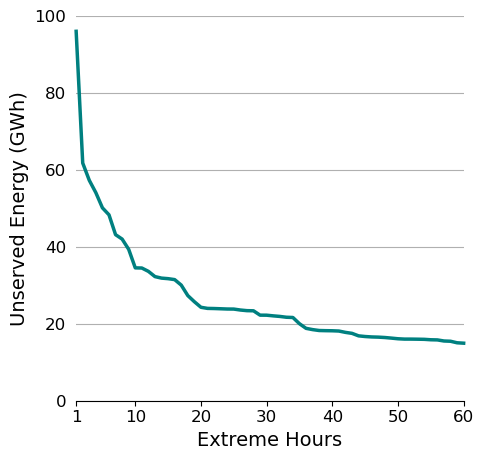

In [16]:
def _plot_unsrved_energy_dist(ax, df, cutoff = 50):
    x_ = range(1, len(df) + 1)
    y_ = df['unserved_energy']/1e3
    ax.plot(x_[:cutoff], y_[:cutoff], lw = 2.5, clip_on = False, color = 'teal')
    ax.set_xlabel('Extreme Hours', fontsize = 14)
    ax.set_ylabel('Unserved Energy (GWh)', fontsize = 14)
    # ax.title('Distribution of Unserved Energy')
    ax.set_xlim(1, cutoff)
    ax.set_ylim(0, )
    ax.xaxis.set_tick_params(labelsize = 12)
    ax.yaxis.set_tick_params(labelsize = 12, left = False)
    ax.spines[['right', 'top', 'left']].set_visible(False)
    ax.set_xticks([1, 10, 20, 30, 40, 50, 60], [1, 10, 20, 30, 40, 50, 60])
    ax.grid(axis = 'y')

fig, ax = plt.subplots(figsize = (5, 5))

_plot_unsrved_energy_dist(ax, df_unserved_energy, cutoff = 60)

plt.savefig(path_to_save_images + '/zone-level_unserved_energy_distribution.png',
            bbox_inches = 'tight',
            dpi         = 600)
plt.savefig(path_to_save_images + '/zone-level_unserved_energy_distribution.pdf',
            bbox_inches = 'tight',
            dpi         = 600)

plt.show()

# Net imports distribution

(16308,)


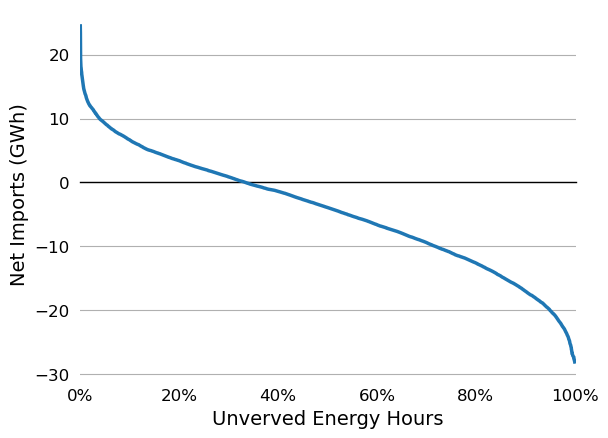

In [17]:
df = df_load_.copy()

# assume df_duration already has ['timepoint','load_zone','net_imports', …]
zone = 'Tamil_Nadu'  # ← replace with the zone you want

# Load shedding greater than 1MW
tau = 1

# This is at the national-level!
df = df.groupby(['timestamp', 'load_zone', 'W', 'H', 'A']).agg({'unserved_energy': 'sum', 'net_imports': 'sum'}).reset_index(drop = False)

df['W'] = df['W'].astype(int)
df['H'] = df['H'].astype(int)
df['A'] = df['A'].astype(int)

df = df.sort_values(by = ['W', 'H', 'A', 'timestamp', 'load_zone'])
df = df.loc[df['timestamp'].isin(df.loc[df['unserved_energy'] > tau, 'timestamp'].unique())].reset_index(drop = True)
df = df[df['load_zone'] == zone]

def plot_net_import_dist(ax, df):
    x_ = range(1, len(df) + 1)
    y_ = df['net_imports'].to_numpy()/1e3
    print(y_.shape)
    ax.plot(np.arange(y_.shape[0], dtype = int), np.sort(y_)[::-1], lw = 2.5, clip_on = True, zorder = 5)
    ax.set_xlabel('Unverved Energy Hours', fontsize = 14)
    ax.set_ylabel('Net Imports (GWh)', fontsize = 14)
    # ax.title('Distribution of Unserved Energy')
    ax.set_xlim(-25, y_.shape[0] + 25)
    ax.xaxis.set_tick_params(labelsize = 12, bottom = False)
    ax.yaxis.set_tick_params(labelsize = 12, left = False)
    ax.spines[['right', 'top', 'left','bottom']].set_visible(False)
    ax.set_xticks(np.linspace(0, y_.shape[0], 6), [f'{i*20}%' for i in np.arange(6, dtype = int)])
    ax.axhline(0, linewidth = 1.,
                  linestyle = '-',
                  color     = 'k',
                  clip_on   = False, 
                  zorder    = 4)
    
    ax.grid(axis   = 'y', 
            zorder = 1)

fig = plt.figure()
ax  = fig.add_subplot(111)

plot_net_import_dist(ax, df)

In [18]:
# assume df_duration already has ['timepoint','load_zone','net_imports', …]
zone = 'Karnataka'  # ← replace with the zone you want

# 1. filter out zeros and unwanted columns
df_zone = (df_duration.loc[df_duration['net_imports'] != 0, ['timepoint','load_zone','net_imports']])

# 2. keep only your zone
df_zone = df_zone[df_zone['load_zone'] == zone]

# 3. group by timepoint and sum
df_zone_import = (df_zone.groupby('timepoint', as_index=False)['net_imports'].sum())

# 4. sort if you like
df_zone_import = df_zone_import.sort_values('net_imports', ascending=False)

print(df_zone_import.head())

       timepoint    net_imports
8707  2041032920  256125.984169
139   2040040620  255842.400679
43    2040040220  253583.977270
8539  2041032220  252392.000706
8059  2041030220  252226.942242


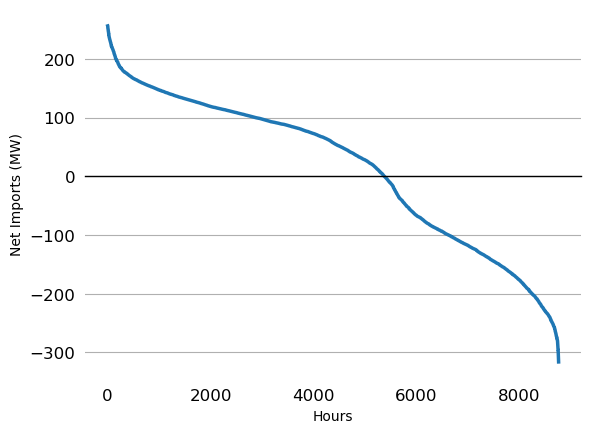

In [19]:
def plot_net_import_dist(ax, df):
    x_ = range(1, len(df) + 1)
    y_ = df['net_imports']/1e3

    ax.plot(x_, y_, lw = 2.5)
    ax.set_xlabel('Hours')
    ax.set_ylabel('Net Imports (MW)')
    # ax.title('Distribution of Unserved Energy')
    # ax.set_xlim(0.9,50)
    # ax.set_ylim(0, )
    ax.xaxis.set_tick_params(labelsize = 12, bottom = False)
    ax.yaxis.set_tick_params(labelsize = 12, left = False)
    ax.spines[['right', 'top', 'left','bottom']].set_visible(False)
    # ax.set_xticks([1, 10, 20, 30, 40, 50], [1, 10, 20, 30, 40, 50])
    ax.grid(axis = 'y')
    ax.axhline(0, linewidth = 1.,
                  linestyle = '-',
                  color     = 'k',
                  clip_on   = False)

fig = plt.figure()
ax = fig.add_subplot(111)

plot_net_import_dist(ax, df_zone_import)

# Load and processing project timepoints

In [20]:
# Load and processing project timepoints
def _processing_project_timepoints(scenarios_):

    dfs_ = []
    for scenario, path_to_scenarios in zip(scenarios_['scenario'], scenarios_['path']):
        path_to_scenario = os.path.join(path_to_scenarios, scenario)

        for dirpath, dirnames, filenames in os.walk(path_to_scenario):
            # Processing scenarios results folder only
            if dirpath.split('/')[-1] == 'results':
                print(scenario)

                df_ = pd.read_csv(os.path.join(dirpath, 'project_timepoint.csv'), low_memory = False)

                df_ = df_[['timepoint', 
                           'technology', 
                           'load_zone', 
                           'power_mw',
                           'capacity_mw',
                           'starting_energy_mwh', 
                           'charge_mw', 
                           'discharge_mw', 
                           'total_curtailment_mw',
                           'availability_derate']] # availability_derate

                df_ = df_.groupby(['timepoint',
                                   'technology', 
                                   'load_zone']).agg({'power_mw': 'sum',
                                                      'total_curtailment_mw': 'sum',
                                                      'starting_energy_mwh': 'sum',
                                                      'charge_mw': 'sum',
                                                      'discharge_mw': 'sum',
                                                      'capacity_mw' : 'sum',
                                                      'availability_derate': 'mean'}).reset_index(drop = False)

                df_ = df_.rename(columns = {'total_curtailment_mw': 'curtailment_mw',
                                            'starting_energy_mwh': 'energy_mwh',
                                            'availability_derate': 'availability_factor'})

                # Add iteration descriptors to dataframe
                df_['W'] = dirpath.split('/')[-4].split('_')[-1]
                df_['H'] = dirpath.split('/')[-3].split('_')[-1]
                df_['A'] = dirpath.split('/')[-2].split('_')[-1]
                
                dfs_.append(df_)

    return pd.concat(dfs_).reset_index(drop = True)

# Group project timepoints by technology
def _group_technology_in_project_timepoints(df_, tech_labels_):

    for group in tech_labels_['group'].unique():
        df_.loc[df_['technology'].isin(tech_labels_.loc[tech_labels_['group'] == group, 'technology']), 'technology'] = group
        
    return df_.groupby(['timepoint',
                        'technology', 
                        'load_zone',
                        'W','H','A']).agg({'power_mw': 'sum',
                                           'capacity_mw' : 'sum',
                                           'curtailment_mw': 'sum',
                                           'energy_mwh': 'sum',
                                           'charge_mw': 'sum',
                                           'discharge_mw': 'sum',
                                           'availability_factor': 'mean'}).reset_index(drop = False)

# Load, process and group project timepoints
df_dispatch_ = _processing_project_timepoints(scenarios_)
df_dispatch_ = _group_technology_in_project_timepoints(df_dispatch_, tech_labels_)
print(df_dispatch_.head())

pier_no_prm_no_ccap_2040_1
pier_no_prm_no_ccap_2040_2
pier_no_prm_no_ccap_2040_3
pier_no_prm_no_ccap_2040_4
pier_no_prm_no_ccap_2040_5
pier_no_prm_no_ccap_2040_6
pier_no_prm_no_ccap_2040_7
pier_no_prm_no_ccap_2040_8
pier_no_prm_no_ccap_2040_9
pier_no_prm_no_ccap_2040_10
pier_no_prm_no_ccap_2040_11
pier_no_prm_no_ccap_2040_12
pier_no_prm_no_ccap_2040_13
pier_no_prm_no_ccap_2040_14
pier_no_prm_no_ccap_2040_15
pier_no_prm_no_ccap_2040_16
pier_no_prm_no_ccap_2040_17
pier_no_prm_no_ccap_2040_18
    timepoint technology       load_zone   W   H   A     power_mw  \
0  2040040101    Battery  Andhra_Pradesh   1   1   1  -495.379236   
1  2040040101    Battery  Andhra_Pradesh  10  10  10  -780.431606   
2  2040040101    Battery  Andhra_Pradesh  11  11  11     0.000000   
3  2040040101    Battery  Andhra_Pradesh  12  12  12 -1661.835078   
4  2040040101    Battery  Andhra_Pradesh  13  13  13     0.000000   

   capacity_mw  curtailment_mw   energy_mwh    charge_mw  discharge_mw  \
0  1678.621291  

#import transmission

In [21]:
# Load and process transmission_timepoint.csv
def _processing_transmission_timepoints(scenarios_):
    dfs_ = []
    for scenario, path_to_scenarios in zip(scenarios_['scenario'], scenarios_['path']):
        path_to_scenario = os.path.join(path_to_scenarios, scenario)

        for dirpath, _, filenames in os.walk(path_to_scenario):
            if dirpath.split('/')[-1] == 'results':
                print(f"Processing transmission_timepoint for {scenario}")

                df_ = pd.read_csv(os.path.join(dirpath, 'transmission_timepoint.csv'), low_memory=False)
                df_ = df_[[
                    'timepoint',
                    'load_zone_from',
                    'load_zone_to',
                    'transmission_flow_mw',
                    'transmission_losses_lz_from',
                    'transmission_losses_lz_to'
                ]]
                df_ = df_.groupby(
                    ['timepoint', 'load_zone_from', 'load_zone_to']
                ).agg({
                    'transmission_flow_mw': 'sum',
                    'transmission_losses_lz_from': 'sum', 
                    'transmission_losses_lz_to': 'sum'
                }).reset_index()

                # Make flow non-negative (use absolute values)
                df_['transmission_flow_mw'] = df_['transmission_flow_mw'].abs()

                # Add iteration descriptors
                df_['W'] = dirpath.split('/')[-4].split('_')[-1]
                df_['H'] = dirpath.split('/')[-3].split('_')[-1]
                df_['A'] = dirpath.split('/')[-2].split('_')[-1]

                dfs_.append(df_)

    return pd.concat(dfs_).reset_index(drop=True)


# Load and process transmission_period.csv
def _processing_transmission_period(scenarios_):
    dfz_ = []
    for scenario, path_to_scenarios in zip(scenarios_['scenario'], scenarios_['path']):
        path_to_scenario = os.path.join(path_to_scenarios, scenario)

        for dirpath, _, filenames in os.walk(path_to_scenario):
            if dirpath.split('/')[-1] == 'results':
                print(f"Processing transmission_period for {scenario}")

                df_2 = pd.read_csv(os.path.join(dirpath, 'transmission_period.csv'), low_memory=False)
                df_2 = df_2[['load_zone_from', 'load_zone_to', 'max_mw']]
                df_2 = df_2.groupby(
                    ['load_zone_from', 'load_zone_to']
                ).agg({'max_mw': 'sum'}).reset_index()

                # Add iteration descriptors
                df_2['W'] = dirpath.split('/')[-4].split('_')[-1]
                df_2['H'] = dirpath.split('/')[-3].split('_')[-1]
                df_2['A'] = dirpath.split('/')[-2].split('_')[-1]

                dfz_.append(df_2)

    return pd.concat(dfz_).reset_index(drop=True)


def add_max_mw_to_timepoints(df_timepoints, df_period):
    """
    Left-join max_mw onto transmission timepoints using
    (load_zone_from, load_zone_to, W, H, A) as keys.
    """
    keys = ['load_zone_from', 'load_zone_to', 'W', 'H', 'A']

    # Ensure period table is unique per key; if not, sum max_mw across duplicates
    df_period_u = (
        df_period
        .groupby(keys, as_index=False, dropna=False)['max_mw']
        .sum()
    )

    # Left-join to keep all timepoints
    merged = df_timepoints.merge(
        df_period_u, on=keys, how='left', validate='many_to_one'
    )

    # Optional: if any routes didn’t find a match, set max_mw to 0 (or keep NaN)
    merged['max_mw'] = merged['max_mw'].fillna(0)

    return merged


# --- Run pipeline ---
df_transmission_timepoints = _processing_transmission_timepoints(scenarios_)
df_transmission_period    = _processing_transmission_period(scenarios_)
df_transmission_timepoints = add_max_mw_to_timepoints(
    df_transmission_timepoints, df_transmission_period
)

# Build zone-level table: sum absolute flow and max_mw of every line incident to a zone
_cols_ = ['timepoint', 'W', 'H', 'A', 'transmission_flow_mw', 'max_mw']

df_from = (
    df_transmission_timepoints[_cols_ + ['load_zone_from']]
    .rename(columns={'load_zone_from': 'load_zone'})
)

df_to = (
    df_transmission_timepoints[_cols_ + ['load_zone_to']]
    .rename(columns={'load_zone_to': 'load_zone'})
)

df_transmission_timepoints_zone = (
    pd.concat([df_from, df_to], ignore_index=True)
      .groupby(['timepoint', 'W', 'H', 'A', 'load_zone'], as_index=False)
      .agg({
          'transmission_flow_mw': 'sum',
          'max_mw': 'sum'
      })
      .rename(columns={
          'transmission_flow_mw': 'zone_transmission_flow_mw',
          'max_mw': 'zone_max_mw'
      })
)

# Add tx_cap_factor
df_transmission_timepoints_zone['tx_cap_factor'] = (
    df_transmission_timepoints_zone['zone_transmission_flow_mw'] /
    df_transmission_timepoints_zone['zone_max_mw'].replace({0: pd.NA})
)

print(df_transmission_timepoints.head())
print(df_transmission_timepoints_zone.head())

Processing transmission_timepoint for pier_no_prm_no_ccap_2040_1
Processing transmission_timepoint for pier_no_prm_no_ccap_2040_2
Processing transmission_timepoint for pier_no_prm_no_ccap_2040_3
Processing transmission_timepoint for pier_no_prm_no_ccap_2040_4
Processing transmission_timepoint for pier_no_prm_no_ccap_2040_5
Processing transmission_timepoint for pier_no_prm_no_ccap_2040_6
Processing transmission_timepoint for pier_no_prm_no_ccap_2040_7
Processing transmission_timepoint for pier_no_prm_no_ccap_2040_8
Processing transmission_timepoint for pier_no_prm_no_ccap_2040_9
Processing transmission_timepoint for pier_no_prm_no_ccap_2040_10
Processing transmission_timepoint for pier_no_prm_no_ccap_2040_11
Processing transmission_timepoint for pier_no_prm_no_ccap_2040_12
Processing transmission_timepoint for pier_no_prm_no_ccap_2040_13
Processing transmission_timepoint for pier_no_prm_no_ccap_2040_14
Processing transmission_timepoint for pier_no_prm_no_ccap_2040_15
Processing transmis

In [22]:
# Add timestamp to df_transmission_timepoints
tp = df_transmission_timepoints['timepoint'].astype(str)

# First 8 chars are YYYYMMDD, rest are hour index
dates = tp.str[:8]
hours = tp.str[8:].astype(int)  # 1–24

df_transmission_timepoints['timestamp'] = (
    pd.to_datetime(dates, format='%Y%m%d')
    + pd.to_timedelta(hours, unit='h')
)

# Reorder so timestamp is the first column
cols = df_transmission_timepoints.columns.tolist()
cols.insert(0, cols.pop(cols.index('timestamp')))
df_transmission_timepoints = df_transmission_timepoints[cols]


In [23]:
# add tiemstamp to df_dispatch_
# Create a timestamp column from 'timepoint' field (YYYYMMDDHH)
tp = df_dispatch_['timepoint'].astype(str)
dates = tp.str[:8]
hours = tp.str[8:].astype(int)  #1-24

df_dispatch_['timestamp'] = (
    pd.to_datetime(dates, format='%Y%m%d')
    + pd.to_timedelta(hours, unit='h')
)
# Reorder so timestamp is first
cols = df_dispatch_.columns.tolist()
cols.insert(0, cols.pop(cols.index('timestamp')))
df_dispatch_ = df_dispatch_[cols]

#Calculation of Renewable Energy Drought

In [24]:
# Filter for Wind and Solar technologies
df_wind = df_dispatch_[df_dispatch_['technology'] == 'Wind']
df_solar = df_dispatch_[df_dispatch_['technology'] == 'Solar']

# Group and sum Wind power and capacity by load_zone and timestamp
wind_grouped = df_wind.groupby(['load_zone', 'timestamp','W','H','A'], as_index=False)[['power_mw', 'capacity_mw']].sum()

# Group and sum Solar power and capacity by load_zone and timestamp
solar_grouped = df_solar.groupby(['load_zone', 'timestamp','W','H','A'], as_index=False)[['power_mw', 'capacity_mw']].sum()

# Merge the grouped Wind and Solar DataFrames
merged_df = pd.merge(
    wind_grouped, 
    solar_grouped, 
    on=['load_zone', 'timestamp','W','H','A'], 
    how='outer', 
    suffixes=('_wind', '_solar')
)

# Sum the Wind and Solar power and capacity into new columns
merged_df['total_renewable_mwh'] = merged_df['power_mw_wind'] + merged_df['power_mw_solar']
merged_df['total_renewable_capacity_mw'] = merged_df['capacity_mw_wind'] + merged_df['capacity_mw_solar']

# Select the final columns - no need for additional grouping
renewable_dispatch = merged_df[['load_zone', 'timestamp', 'W','H','A','total_renewable_mwh', 'total_renewable_capacity_mw']]

# net_cf=renewable_dispatch.copy()
# net_cf['capacity_factor'] = net_cf['total_renewable_mwh'] / net_cf['total_renewable_capacity_mw']

# # filter only the solar hours i.e. 9 AM to 5 PM
# net_cf = net_cf[(net_cf['timestamp'].dt.hour >= 9) & (net_cf['timestamp'].dt.hour < 17)]

# # keep the values whose capacity factor is below 0.025
# net_cf = net_cf[net_cf['capacity_factor'] < 0.025]


# calculation by average Plant load factor method

In [25]:

plf_df = renewable_dispatch.copy()

window_days = 2  

# Convert timestamp to plain date (YYYY-MM-DD)
plf_df['date'] = plf_df['timestamp'].dt.date  

# Aggregate to daily total generation and capacity
daily_df = (
    plf_df.groupby(['load_zone','W','H','A','date'], as_index=False)
          [['total_renewable_mwh','total_renewable_capacity_mw']].sum()
)

# Daily PLF
daily_df['daily_plf'] = (
    daily_df['total_renewable_mwh'] / daily_df['total_renewable_capacity_mw']
)

# Rolling PLF over 2 days
daily_df['plf'] = (
    daily_df.groupby(['load_zone','W','H','A'])['daily_plf']
            .transform(lambda x: x.rolling(window=window_days, min_periods=1).mean())
)

# Final dataframe (date-only, no hh:mm)
plf_df = daily_df.drop(columns=['daily_plf'])


In [26]:
# df_dispatch_ must have: timepoint, technology, load_zone, power_mw, capacity_mw, W, H, A

# 1) Correct timestamp (timepoints encoded as YYYYMMDDHH with HH=1..24)
tp = df_dispatch_['timepoint'].astype(str)
dates = pd.to_datetime(tp.str[:8], format='%Y%m%d')
hours = tp.str[8:].astype(int)  # 1..24
df_dispatch_ = df_dispatch_.copy()
df_dispatch_['timestamp'] = dates + pd.to_timedelta(hours - 1, unit='h')  # <-- fix at source

# 2) Wind & Solar hourly (sum if multiples)
keys = ['load_zone','timestamp','W','H','A']
cols = keys + ['power_mw','capacity_mw','technology']
ws = df_dispatch_.loc[df_dispatch_['technology'].isin(['Wind','Solar']), cols].copy()

wind = (ws[ws['technology']=='Wind']
        .groupby(keys, as_index=False)[['power_mw','capacity_mw']].sum()
        .rename(columns={'power_mw':'power_mw_wind','capacity_mw':'capacity_mw_wind'}))

solar = (ws[ws['technology']=='Solar']
         .groupby(keys, as_index=False)[['power_mw','capacity_mw']].sum()
         .rename(columns={'power_mw':'power_mw_solar','capacity_mw':'capacity_mw_solar'}))

# 3) Merge wind+solar, fill zeros BEFORE summing
merged = (pd.merge(wind, solar, on=keys, how='outer')
            .fillna({'power_mw_wind':0.0, 'capacity_mw_wind':0.0,
                     'power_mw_solar':0.0, 'capacity_mw_solar':0.0}))

merged['total_power_mw']    = merged['power_mw_wind']    + merged['power_mw_solar']
merged['total_capacity_mw'] = merged['capacity_mw_wind'] + merged['capacity_mw_solar']

# 4) Day assignment (NO extra 1h shift now that timestamp is fixed)
merged['date'] = merged['timestamp'].dt.normalize()

# 5) Daily PLF and 48h (2-day) rolling PLF
daily = (merged.groupby(['load_zone','W','H','A','date'], as_index=False)
         .agg(energy_mwh_day=('total_power_mw','sum'),
              cap_hour_sum_day=('total_capacity_mw','sum')))

daily['plf_day'] = np.where(
    daily['cap_hour_sum_day'] > 0,
    daily['energy_mwh_day'] / daily['cap_hour_sum_day'],
    np.nan
)

window_days = 2  # 48 hours
daily = daily.sort_values(['load_zone','W','H','A','date'])
daily['plf'] = (daily.groupby(['load_zone','W','H','A'])['plf_day']
                .transform(lambda s: s.rolling(window=window_days, min_periods=1).mean()))

# 6) Final day-wise PLF dataframe + flag
plf_df = daily[['load_zone','W','H','A','date','plf']].copy()
plf_threshold = 0.025
plf_df['low_plf_flag'] = np.where(plf_df['plf'].notna() & (plf_df['plf'] < plf_threshold), 1, 0).astype('int8')

# 7) Enforce fiscal year window: Apr 1 → Mar 31 (change fy as needed)
fy = 2040  # FY 2040–41
fy_start = pd.Timestamp(f"{fy}-04-01")
fy_end   = pd.Timestamp(f"{fy+1}-03-31")

plf_df = plf_df[(plf_df['date'] >= fy_start) & (plf_df['date'] <= fy_end)].copy()
plf_df = plf_df.sort_values(['load_zone','W','H','A','date']).reset_index(drop=True)


#Calculation of top net demand days 

In [27]:
TOP_K = 5
FY = None           # e.g., 2040 for FY 2040–41 (Apr 1 → Mar 31), or None to skip

# Helper: correct timestamp from timepoint with hours 1..24
def _timestamp_from_timepoint(df, tp_col='timepoint'):
    tp = df[tp_col].astype(str)
    d  = pd.to_datetime(tp.str[:8], format='%Y%m%d')
    h  = tp.str[8:].astype(int)  # 1..24
    return d + pd.to_timedelta(h - 1, unit='h')

# 1) Ensure aligned timestamps on load & dispatch
df_load_ = df_load_.copy()
if 'timestamp' not in df_load_.columns:
    df_load_['timestamp'] = _timestamp_from_timepoint(df_load_)
df_load_['date'] = df_load_['timestamp'].dt.normalize()

df_dispatch_ = df_dispatch_.copy()
if 'timestamp' not in df_dispatch_.columns:
    df_dispatch_['timestamp'] = _timestamp_from_timepoint(df_dispatch_)

# 2) Build hourly RE total (Wind + Solar) per zone/W/H/A/timestamp
keys = ['load_zone','timestamp','W','H','A']
ws = df_dispatch_.loc[df_dispatch_['technology'].isin(['Wind','Solar']),
                      keys + ['power_mw','capacity_mw','technology']].copy()

wind = (ws[ws['technology']=='Wind']
        .groupby(keys, as_index=False)[['power_mw','capacity_mw']].sum()
        .rename(columns={'power_mw':'power_mw_wind','capacity_mw':'capacity_mw_wind'}))

solar = (ws[ws['technology']=='Solar']
         .groupby(keys, as_index=False)[['power_mw','capacity_mw']].sum()
         .rename(columns={'power_mw':'power_mw_solar','capacity_mw':'capacity_mw_solar'}))

re_merged = (pd.merge(wind, solar, on=keys, how='outer')
               .fillna({'power_mw_wind':0.0, 'capacity_mw_wind':0.0,
                        'power_mw_solar':0.0, 'capacity_mw_solar':0.0}))
re_merged['total_re_mw'] = re_merged['power_mw_wind'] + re_merged['power_mw_solar']

# 3) Build netload_df = static_load − total_re_mw (hourly, PER ZONE)
netload_df = pd.merge(
    df_load_[keys + ['static_load']],
    re_merged[keys + ['total_re_mw']],
    on=keys, how='left'
).fillna({'total_re_mw': 0.0})

netload_df['net_load_mw'] = netload_df['static_load'] - netload_df['total_re_mw']
netload_df['date'] = netload_df['timestamp'].dt.normalize()

# (optional) restrict to fiscal year Apr 1 → Mar 31
if FY is not None:
    fy_start = pd.Timestamp(f"{FY}-04-01")
    fy_end   = pd.Timestamp(f"{FY+1}-03-31")
    netload_df = netload_df[(netload_df['date'] >= fy_start) & (netload_df['date'] <= fy_end)].copy()

# 4) Per-zone hourly net load (sum only in case of duplicates)
zone_hourly = (netload_df.groupby(['load_zone','W','H','A','timestamp'], as_index=False)['net_load_mw'].sum())
zone_hourly['date'] = zone_hourly['timestamp'].dt.normalize()

# 5) Per-zone DAILY PEAK net load (MW)
daily_peak_zone = (
    zone_hourly.groupby(['load_zone','W','H','A','date'], as_index=False)['net_load_mw']
               .max()
               .rename(columns={'net_load_mw':'daily_peak_net_load_mw'})
)

# 6) Top 5 days per (load_zone, W, H, A)
top5_zone_netload_days = (
    daily_peak_zone.sort_values(['load_zone','W','H','A','daily_peak_net_load_mw'],
                                ascending=[True, True, True, True, False])
                    .groupby(['load_zone','W','H','A'])
                    .head(TOP_K)
                    .reset_index(drop=True)
)

# (nice to have) rank within each zone+iteration
top5_zone_netload_days['rank'] = (
    top5_zone_netload_days.groupby(['load_zone','W','H','A'])['daily_peak_net_load_mw']
                          .rank(ascending=False, method='first').astype(int)
)

# make date a pure date object (no hh:mm:ss)
top5_zone_netload_days['date'] = pd.to_datetime(top5_zone_netload_days['date']).dt.date

# - netload_df: hourly net load by zone/W/H/A
# - top5_zone_netload_days: top 5 daily-peak net-load days for each (load_zone, W, H, A)


In [28]:
# Merging netyload with plf
# Make dates comparable (no hh:mm)
plf_df = plf_df.copy()
plf_df['date'] = pd.to_datetime(plf_df['date']).dt.date
top5_zone_netload_days['date'] = pd.to_datetime(top5_zone_netload_days['date']).dt.date

# Align dtypes on join keys
for c in ['load_zone','W','H','A']:
    plf_df[c] = plf_df[c].astype(str)
    top5_zone_netload_days[c] = top5_zone_netload_days[c].astype(str)

# Keys
keys = ['load_zone','W','H','A','date']

# Build the flag from the top-5 table
top5_keys = top5_zone_netload_days[keys].drop_duplicates().assign(net_load=1)

# Merge into plf_df; fill others as 0
plf_df = (
    plf_df.drop(columns=['net_load'], errors='ignore')
          .merge(top5_keys, on=keys, how='left')
)
plf_df['net_load'] = plf_df['net_load'].fillna(0).astype('int8')

In [29]:
# Adding unserved energy to plf
# --- make dates comparable (no hh:mm) ---
plf_df = plf_df.copy()
plf_df['date'] = pd.to_datetime(plf_df['date']).dt.date

df_ls = df_load_.copy()

# If df_load_ doesn't already have the fixed timestamp (1..24 → hours-1), build it:
if 'timestamp' not in df_ls.columns:
    tp = df_ls['timepoint'].astype(str)
    d  = pd.to_datetime(tp.str[:8], format='%Y%m%d')
    h  = tp.str[8:].astype(int)  # 1..24
    df_ls['timestamp'] = d + pd.to_timedelta(h - 1, unit='h')

df_ls['date'] = df_ls['timestamp'].dt.date

# --- build daily presence flag for load shedding (>0) per zone & W,H,A ---
keys = ['load_zone','W','H','A','date']
ls_presence = (
    df_ls.loc[df_ls['unserved_energy'] > 0, keys]
         .drop_duplicates()
         .assign(load_shedding=1)
)

# align dtypes on join keys (avoid int/str mismatches)
for k in ['load_zone','W','H','A']:
    plf_df[k]      = plf_df[k].astype(str)
    ls_presence[k] = ls_presence[k].astype(str)

# --- merge into plf_df; fill others as 0 ---
plf_df = (
    plf_df.drop(columns=['load_shedding'], errors='ignore')
          .merge(ls_presence, on=keys, how='left')
)
plf_df['load_shedding'] = plf_df['load_shedding'].fillna(0).astype('int8')


# Dataframe with weather indices and impact on LOL

In [30]:

# ---- keys we’ll reuse ----
keys4 = ['load_zone','W','H','A']

# start from plf_df
final_df = plf_df.copy()
final_df['date'] = pd.to_datetime(final_df['date']).dt.normalize()

# =========================
# 1) Expected EUE per (zone, W, H, A) and daily load shedding
# =========================
ls = df_load_.copy()

# ensure a correct hourly timestamp (1..24 encoded hours → hours-1)
if 'timestamp' not in ls.columns:
    tp = ls['timepoint'].astype(str)
    d  = pd.to_datetime(tp.str[:8], format='%Y%m%d')
    h  = tp.str[8:].astype(int)  # 1..24
    ls['timestamp'] = d + pd.to_timedelta(h - 1, unit='h')

ls['date'] = ls['timestamp'].dt.normalize()

# (optional but helps keep “one year” aligned with plf_df’s span)
ls = ls.merge(final_df[keys4].drop_duplicates(), on=keys4, how='inner')
ls = ls[(ls['date'] >= final_df['date'].min()) & (ls['date'] <= final_df['date'].max())]

# daily unserved energy per zone & iteration (assumes hourly steps → sum(MW)=MWh)
ls_daily = (
    ls.groupby(keys4 + ['date'], as_index=False)['unserved_energy']
      .sum()
      .rename(columns={'unserved_energy': 'load_shedding_mwh'})
)

# expected EUE over the year window (per zone & iteration)
expected_eue = (
    ls_daily.groupby(keys4, as_index=False)['load_shedding_mwh']
            .sum()
            .rename(columns={'load_shedding_mwh':'expected_eue_mwh'})
)

# merge into final_df
final_df = final_df.merge(ls_daily, on=keys4 + ['date'], how='left')
final_df['load_shedding_mwh'] = final_df['load_shedding_mwh'].fillna(0)

final_df = final_df.merge(expected_eue, on=keys4, how='left')
final_df['expected_eue_mwh'] = final_df['expected_eue_mwh'].fillna(0)

# ratio: daily load shedding as a share of expected EUE
final_df['load_shedding_eue'] = np.where(
    final_df['expected_eue_mwh'] > 0,
    final_df['load_shedding_mwh'] / final_df['expected_eue_mwh'],
    np.nan
)

# =========================
# 2) Ratio to maximum of top net load
# =========================
nl = netload_df.copy()
nl['timestamp'] = pd.to_datetime(nl['timestamp'])
nl['date'] = nl['timestamp'].dt.normalize()

# daily PEAK net load (MW)
nl_daily_peak = (
    nl.groupby(keys4 + ['date'], as_index=False)['net_load_mw']
      .max()
      .rename(columns={'net_load_mw':'daily_peak_netload_mw'})
)

# max of the top-5 daily peaks per (zone, W, H, A)
top5_max = (
    nl_daily_peak.sort_values(keys4 + ['daily_peak_netload_mw'],
                              ascending=[True, True, True, True, False])
                 .groupby(keys4, as_index=False).head(5)
                 .groupby(keys4, as_index=False)['daily_peak_netload_mw']
                 .max()
                 .rename(columns={'daily_peak_netload_mw':'top_netload_max_mw'})
)

# merge denom and compute ratio
final_df = final_df.merge(top5_max, on=keys4, how='left')
final_df['load_shedding_top_net_load'] = np.where(
    final_df['top_netload_max_mw'] > 0,
    final_df['load_shedding_mwh'] / final_df['top_netload_max_mw'],
    np.nan
)

# date as plain date (no time)
final_df['date'] = final_df['date'].dt.date


# Heatmap of Renewable Energy Drought days

/tmp/ipykernel_1233503/1768223499.py:50: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  (df_dispatch_['technology'].str.contains(therm_pat, case=False, na=False)),
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: 

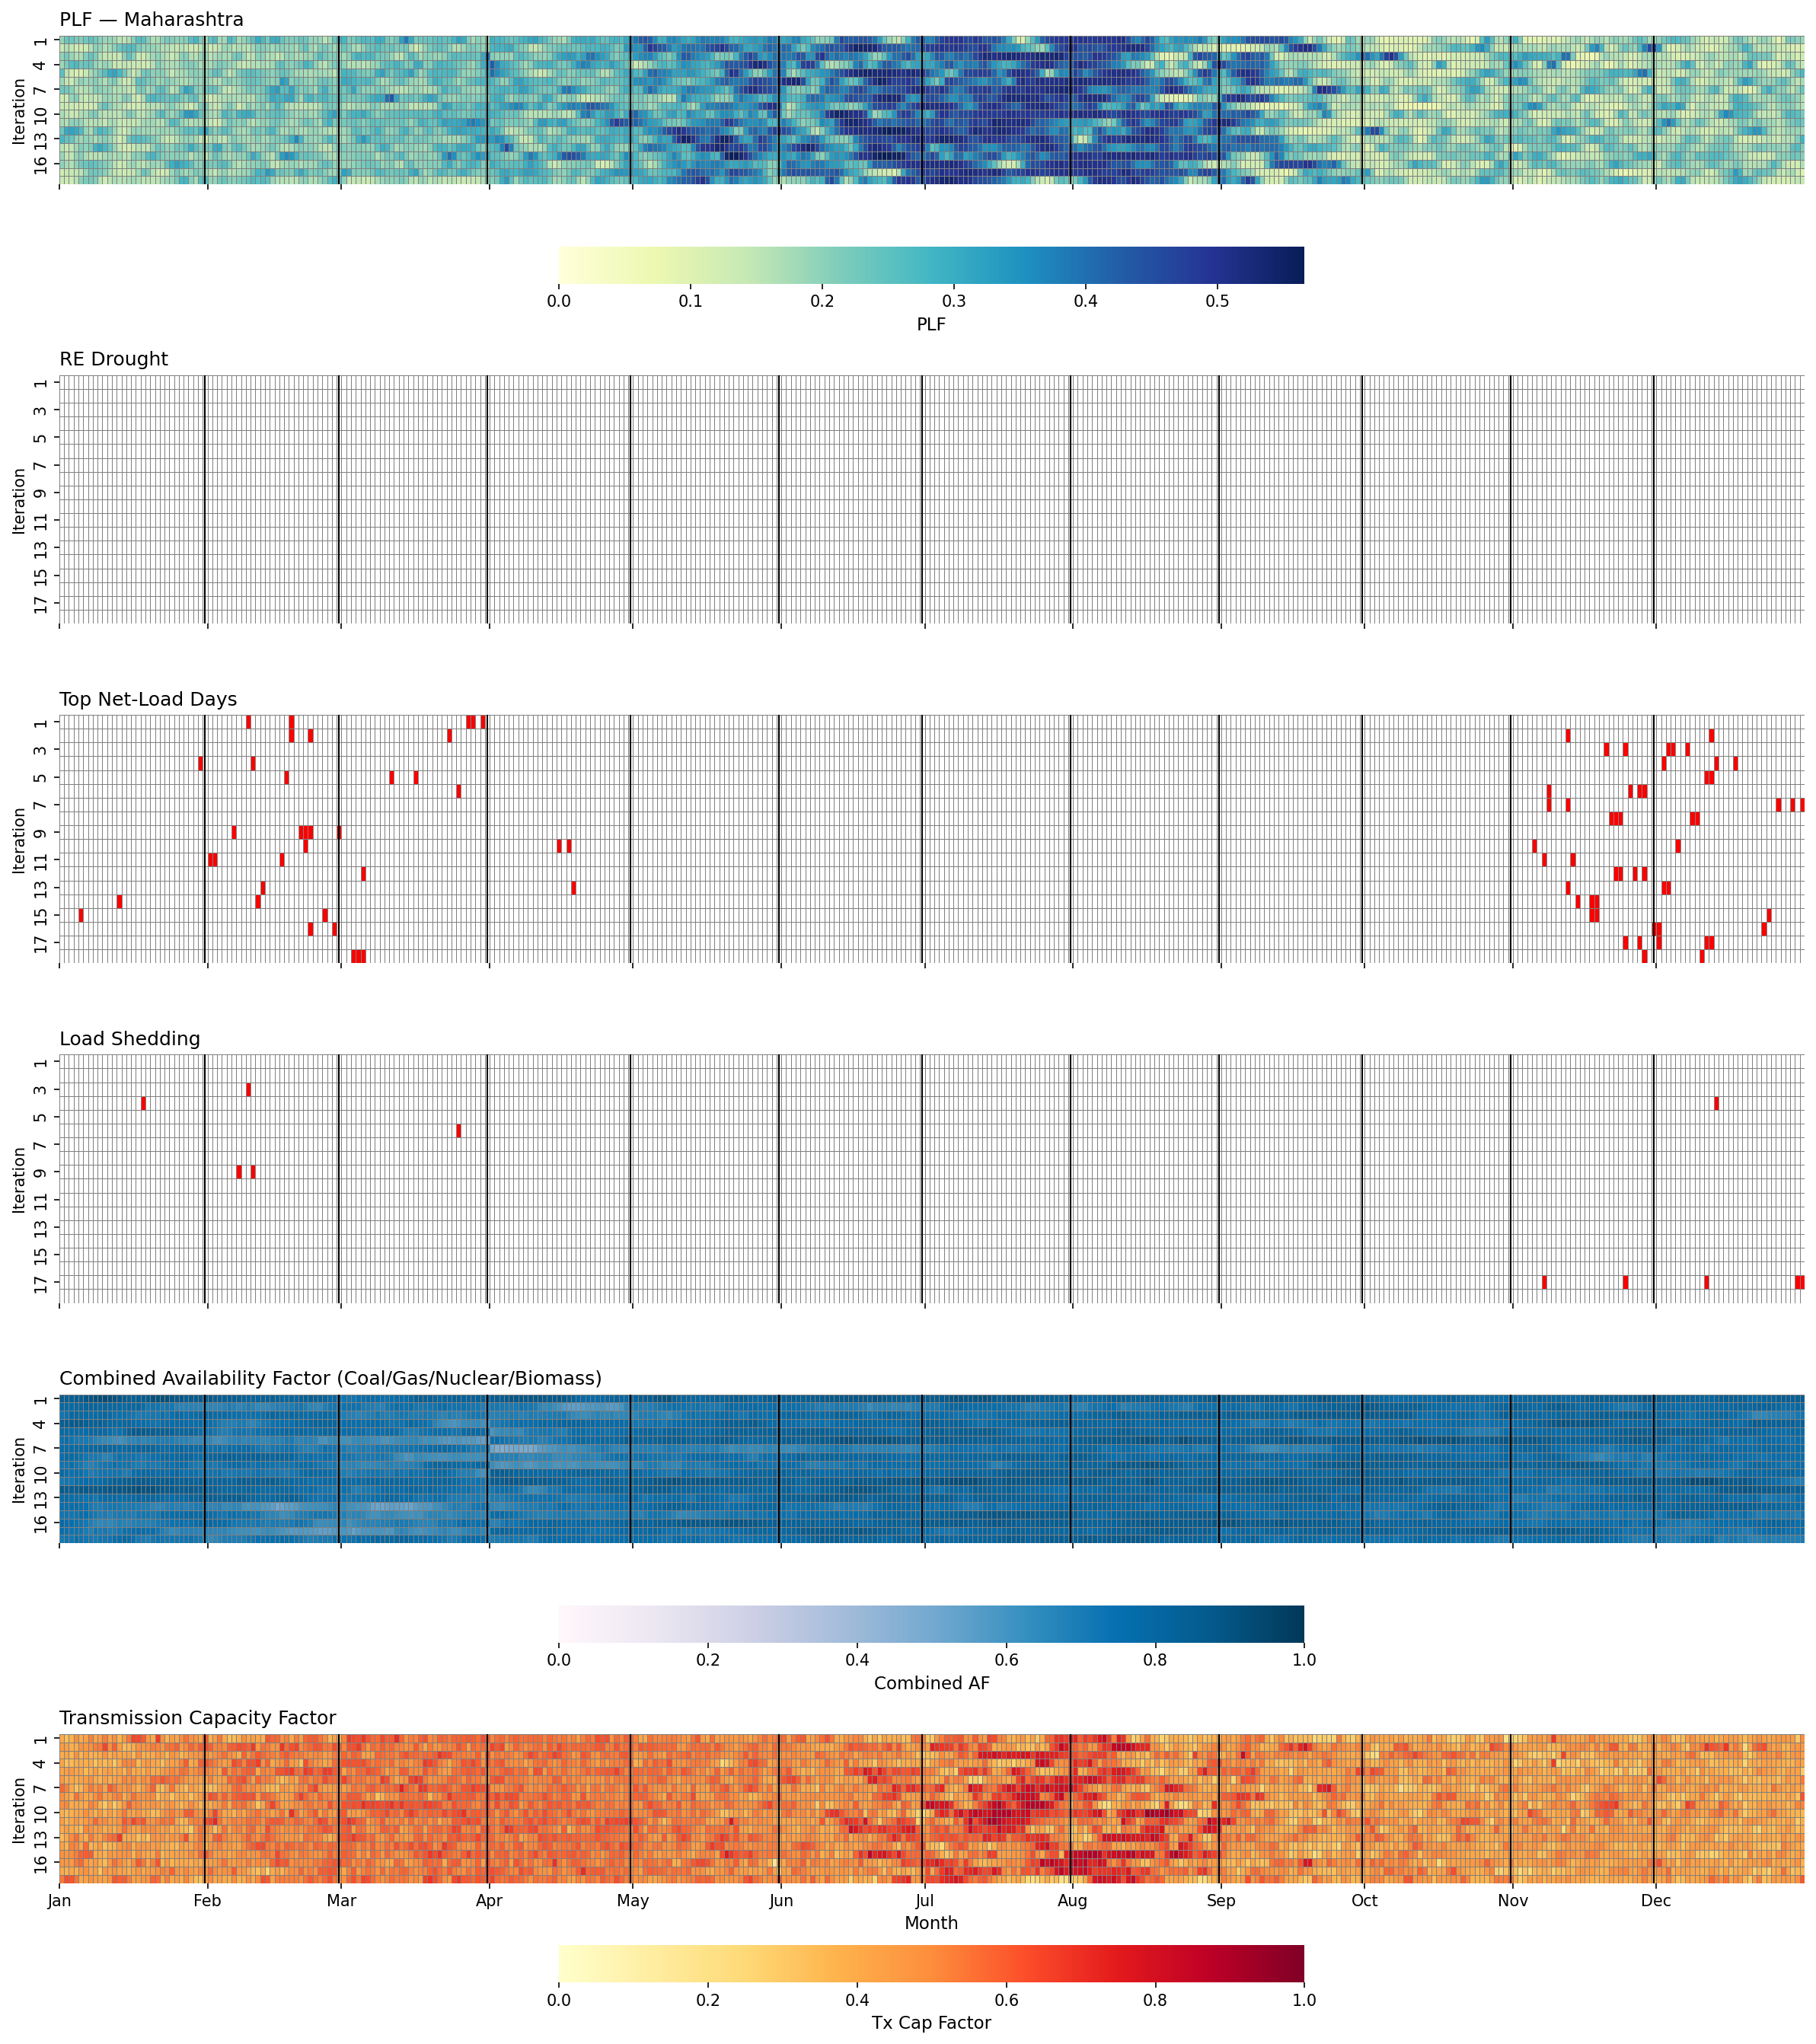

In [31]:


selected_zone = "Maharashtra"  # ← change here to switch zones
freq = "D"               # "D" daily; e.g., "W-MON" for weekly display
plt.rcParams.update({"font.family": "Arial", "font.size": 10})


def build_zone_mats(selected_zone, plf_df, df_transmission_timepoints_zone, df_dispatch_, freq="D"):
    # ---- Ensure df_dispatch_ has correct timestamp (1..24 → hours-1) ----
    if 'timestamp' not in df_dispatch_.columns:
        tp    = df_dispatch_['timepoint'].astype(str)
        dates = pd.to_datetime(tp.str[:8], format='%Y%m%d')
        hours = tp.str[8:].astype(int)
        df_dispatch_ = df_dispatch_.copy()
        df_dispatch_['timestamp'] = dates + pd.to_timedelta(hours - 1, unit='h')

    # ---- PLF-side (zone slice) ----
    z = plf_df.loc[
        plf_df['load_zone'] == selected_zone,
        ['W','H','A','date','plf','low_plf_flag','net_load','load_shedding']
    ].copy()
    if z.empty:
        raise ValueError(f"No PLF rows for '{selected_zone}'. "
                         f"Available: {sorted(plf_df['load_zone'].unique())}")
    z['date'] = pd.to_datetime(z['date']).dt.normalize()
    z[['W','H','A']] = z[['W','H','A']].astype(str)
    it_plf = z[['W','H','A']].drop_duplicates()

    # ---- TX-side (zone slice) ----
    tx = df_transmission_timepoints_zone.loc[
        df_transmission_timepoints_zone['load_zone'] == selected_zone,
        ['timepoint','W','H','A','load_zone','tx_cap_factor']
    ].copy()
    if tx.empty:
        tx_daily = pd.DataFrame(columns=['W','H','A','date','tx_cap_factor'])
        it_tx = pd.DataFrame(columns=['W','H','A'])
    else:
        if 'timestamp' not in tx.columns:
            tp    = tx['timepoint'].astype(str)
            dates = pd.to_datetime(tp.str[:8], format='%Y%m%d')
            hours = tp.str[8:].astype(int)
            tx['timestamp'] = dates + pd.to_timedelta(hours - 1, unit='h')
        tx['date'] = tx['timestamp'].dt.normalize()
        tx[['W','H','A']] = tx[['W','H','A']].astype(str)
        tx_daily = tx.groupby(['W','H','A','date'], as_index=False)['tx_cap_factor'].mean()
        it_tx = tx_daily[['W','H','A']].drop_duplicates()

    # ---- Combined Availability Factor (Coal/Gas/CCGT/CT/Nuclear/Biomass) ----
    therm_pat = r'(coal|gas|ccgt|ct|nuclear|biomass)'
    disp = df_dispatch_.loc[
        (df_dispatch_['load_zone'] == selected_zone) &
        (df_dispatch_['technology'].str.contains(therm_pat, case=False, na=False)),
        ['load_zone','timestamp','W','H','A','technology','power_mw','capacity_mw'] +
        ([c for c in ['availability_derate','availability_factor'] if c in df_dispatch_.columns])
    ].copy()
    disp['date'] = disp['timestamp'].dt.normalize()
    disp[['W','H','A']] = disp[['W','H','A']].astype(str)

    if 'availability_derate' in disp.columns:
        disp['af_src'] = disp['availability_derate']
    elif 'availability_factor' in disp.columns:
        disp['af_src'] = disp['availability_factor']
    else:
        disp['af_src'] = np.where(
            disp['capacity_mw'] > 0,
            (disp['power_mw'] / disp['capacity_mw']).clip(0, 1),
            np.nan
        )

    keys_ts = ['load_zone','timestamp','W','H','A']
    caf_ts = (disp.assign(weighted=disp['capacity_mw'] * disp['af_src'])
                    .groupby(keys_ts, as_index=False)
                    .agg(caf_num=('weighted','sum'),
                         caf_den=('capacity_mw','sum')))
    caf_ts['caf'] = np.where(caf_ts['caf_den'] > 0, caf_ts['caf_num'] / caf_ts['caf_den'], np.nan)
    caf_ts['date'] = caf_ts['timestamp'].dt.normalize()
    caf_daily = caf_ts.groupby(['W','H','A','date'], as_index=False)['caf'].mean()
    it_caf = caf_daily[['W','H','A']].drop_duplicates()

    # ---- Master iteration list = union(PLF, TX, CAF) ----
    it_master = (pd.concat([it_plf, it_tx, it_caf], ignore_index=True)
                   .drop_duplicates()
                   .sort_values(['W','H','A'])
                   .reset_index(drop=True))
    it_master['iteration'] = np.arange(1, len(it_master) + 1)

    # Attach iteration ids
    z = z.merge(it_master, on=['W','H','A'], how='left')
    caf_daily = caf_daily.merge(it_master, on=['W','H','A'], how='left')

    # ---- Pivot PLF matrices and resample ----
    heat = (z.pivot_table(index='iteration', columns='date', values='plf',          aggfunc='mean')
              .T.resample(freq).mean().T)
    flag = (z.pivot_table(index='iteration', columns='date', values='low_plf_flag', aggfunc='max' )
              .T.resample(freq).max().T)
    net  = (z.pivot_table(index='iteration', columns='date', values='net_load',     aggfunc='max' )
              .T.resample(freq).max().T)
    shed = (z.pivot_table(index='iteration', columns='date', values='load_shedding',aggfunc='max' )
              .T.resample(freq).max().T)

    # Full date axis across PLF, TX, CAF
    plf_cols = heat.columns if heat.shape[1] else pd.Index([])
    tx_cols  = pd.to_datetime(tx_daily['date']).sort_values().unique() if len(tx_daily) else pd.Index([])
    caf_cols = pd.to_datetime(caf_daily['date']).sort_values().unique() if len(caf_daily) else pd.Index([])
    cols_all = [c for c in [plf_cols, tx_cols, caf_cols] if len(c)]
    if cols_all:
        full_start = min(c.min() for c in cols_all)
        full_end   = max(c.max() for c in cols_all)
    else:
        raise ValueError(f"No dates found for '{selected_zone}'.")

    full_cols = pd.date_range(pd.to_datetime(full_start), pd.to_datetime(full_end), freq=freq)

    # Reindex PLF mats to master iters & full date axis
    heat = heat.reindex(index=it_master['iteration'].to_numpy(), columns=full_cols)
    flag = flag.reindex(index=heat.index, columns=heat.columns, fill_value=0)
    net  = net .reindex(index=heat.index, columns=heat.columns, fill_value=0)
    shed = shed.reindex(index=heat.index, columns=heat.columns, fill_value=0)

    # TX & CAF to same grid
    if len(tx_daily):
        tx_daily = tx_daily.merge(it_master, on=['W','H','A'], how='left')
        tx_mat = (tx_daily.pivot_table(index='iteration', columns='date', values='tx_cap_factor', aggfunc='mean')
                            .T.resample(freq).mean().T)
        tx_mat = tx_mat.reindex(index=heat.index, columns=heat.columns)
    else:
        tx_mat = pd.DataFrame(index=heat.index, columns=heat.columns, data=np.nan)
    if len(caf_daily):
        caf_mat = (caf_daily.pivot_table(index='iteration', columns='date', values='caf', aggfunc='mean')
                             .T.resample(freq).mean().T)
        caf_mat = caf_mat.reindex(index=heat.index, columns=heat.columns)
    else:
        caf_mat = pd.DataFrame(index=heat.index, columns=heat.columns, data=np.nan)

    # Rotate so x-axis starts at January
    cols_dt = pd.to_datetime(heat.columns)
    jan_idx = np.where(cols_dt.month == 1)[0]
    if len(jan_idx) > 0:
        start = jan_idx[0]
        order = np.r_[start:len(cols_dt), 0:start]
        heat   = heat.iloc[:, order]
        flag   = flag.iloc[:, order]
        net    = net .iloc[:, order]
        shed   = shed.iloc[:, order]
        caf_mat= caf_mat.iloc[:, order]
        tx_mat = tx_mat.iloc[:, order]
        cols_dt = cols_dt[order]

    # Month ticks & labels
    p = cols_dt.to_period('M')
    month_starts = np.r_[0, np.where(p[1:] != p[:-1])[0] + 1]
    month_labels = cols_dt[month_starts].strftime('%b')

    return it_master, heat, flag, net, shed, caf_mat, tx_mat, month_starts, month_labels

# =========================
# PLOT — stacked panels, thin grids, inset colorbars (PLF, CAF, TX)
# =========================
def plot_zone_dashboard_big_legends(selected_zone,
                                    plf_df,
                                    df_transmission_timepoints_zone,
                                    df_dispatch_,
                                    freq="D"):
    it_master, heat, flag, net, shed, caf_mat, tx_mat, month_starts, month_labels = \
        build_zone_mats(selected_zone, plf_df, df_transmission_timepoints_zone, df_dispatch_, freq=freq)

    # Make figure taller & wider
    fig, axes = plt.subplots(6, 1, figsize=(16, 18), dpi=150, sharex=True)
    ax_plf, ax_flag, ax_net, ax_shed, ax_caf, ax_tx = axes

    # Panel 1: PLF
    vmax = float(np.nanmax(heat.values)) if np.isfinite(np.nanmax(heat.values)) else 1.0
    hm_plf = sns.heatmap(
        heat, ax=ax_plf,
        cmap="YlGnBu", vmin=0, vmax=vmax,
        linewidths=0.4, linecolor="grey",
        cbar=True, cbar_kws={"orientation":"horizontal", "pad":0.25, "shrink":0.6}
    )
    ax_plf.set_title(f"PLF — {selected_zone}", loc="left")
    ax_plf.set_ylabel("Iteration")
    hm_plf.figure.axes[-1].set_xlabel("PLF", fontsize=11)

    # Panel 2: RE drought
    sns.heatmap(
        flag, ax=ax_flag,
        cmap=ListedColormap(['white','red']), vmin=0, vmax=1,
        linewidths=0.4, linecolor="grey",
        cbar=False
    )
    ax_flag.set_title("RE Drought", loc="left")
    ax_flag.set_ylabel("Iteration")

    # Panel 3: Top net-load
    sns.heatmap(
        net, ax=ax_net,
        cmap=ListedColormap(['white','red']), vmin=0, vmax=1,
        linewidths=0.4, linecolor="grey",
        cbar=False
    )
    ax_net.set_title("Top Net-Load Days ", loc="left")
    ax_net.set_ylabel("Iteration")

    # Panel 4: Load shedding
    sns.heatmap(
        shed, ax=ax_shed,
        cmap=ListedColormap(['white','red']), vmin=0, vmax=1,
        linewidths=0.4, linecolor="grey",
        cbar=False
    )
    ax_shed.set_title("Load Shedding", loc="left")
    ax_shed.set_ylabel("Iteration")

    # Panel 5: Combined AF
    hm_caf = sns.heatmap(
        caf_mat, ax=ax_caf,
        cmap="PuBu", vmin=0, vmax=1,
        linewidths=0.4, linecolor="grey",
        cbar=True, cbar_kws={"orientation":"horizontal", "pad":0.25, "shrink":0.6}
    )
    ax_caf.set_title("Combined Availability Factor (Coal/Gas/Nuclear/Biomass)", loc="left")
    ax_caf.set_ylabel("Iteration")
    hm_caf.figure.axes[-1].set_xlabel("Combined AF", fontsize=11)

    # Panel 6: Transmission factor
    hm_tx = sns.heatmap(
        tx_mat, ax=ax_tx,
        cmap="YlOrRd", vmin=0, vmax=1,
        linewidths=0.4, linecolor="grey",
        cbar=True, cbar_kws={"orientation":"horizontal", "pad":0.25, "shrink":0.6}
    )
    ax_tx.set_title("Transmission Capacity Factor", loc="left")
    ax_tx.set_ylabel("Iteration")
    hm_tx.figure.axes[-1].set_xlabel("Tx Cap Factor", fontsize=11)

    # X-axis months only at bottom
    ax_tx.set_xticks(month_starts)
    ax_tx.set_xticklabels(month_labels, rotation=0, fontsize=10)
    ax_tx.set_xlabel("Month", fontsize=11)

    # Month separators
    for ax in axes:
        for x in month_starts[1:]:
            ax.axvline(x-0.5, color="black", linewidth=1.0)

    plt.tight_layout()
    plt.show()

plot_zone_dashboard_big_legends(selected_zone, plf_df, df_transmission_timepoints_zone, df_dispatch_, freq=freq)

/tmp/ipykernel_1233503/558412534.py:144: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  (disp['technology'].str.contains(therm_pat, case=False, na=False)),
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font fam

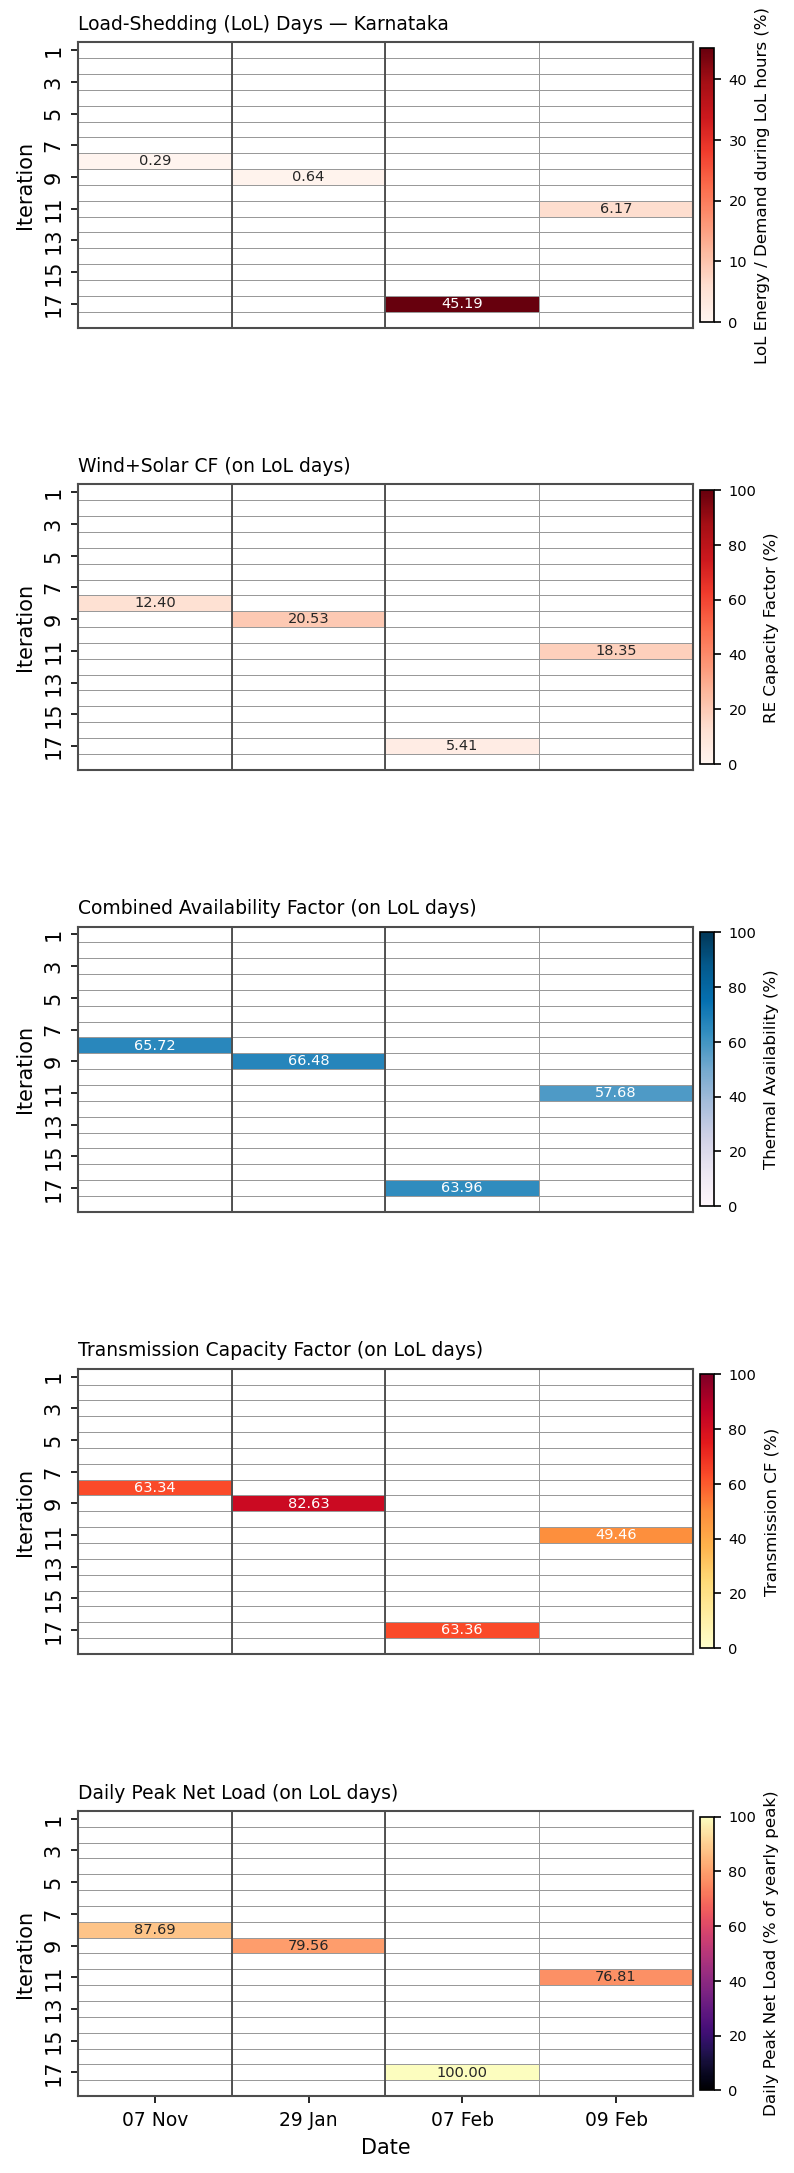

In [ ]:

selected_zone = "Kerala"  
FY            = None          # e.g., 2040 for fiscal year Apr→Mar; or None to skip

plt.rcParams.update({"font.family": "Arial", "font.size": 10})

def _timestamp_from_timepoint(df, tp_col='timepoint'):
    """Convert YYYYMMDDHH (HH=1..24) → pandas Timestamp (hour-1)."""
    tp = df[tp_col].astype(str)
    d  = pd.to_datetime(tp.str[:8], format='%Y%m%d')
    h  = tp.str[8:].astype(int)      # 1..24
    return d + pd.to_timedelta(h - 1, unit='h')

def _ensure_timestamp(df, tp_col='timepoint'):
    if 'timestamp' not in df.columns:
        df = df.copy()
        df['timestamp'] = _timestamp_from_timepoint(df, tp_col)
    return df

def _norm(df):
    """Normalize date column and cast W/H/A to str if present."""
    out = df.copy()
    if 'timestamp' in out.columns:
        out['date'] = out['timestamp'].dt.normalize()
    if 'date' in out.columns:
        out['date'] = pd.to_datetime(out['date']).dt.normalize()
    for c in ['W','H','A']:
        if c in out.columns:
            out[c] = out[c].astype(str)
    return out

def _apply_fy(df, fy, date_col='date'):
    """Filter to fiscal year Apr 1 (FY) → Mar 31 (FY+1)."""
    if fy is None:
        return df
    start = pd.Timestamp(f"{fy}-04-01")
    end   = pd.Timestamp(f"{fy+1}-03-31")
    return df[(df[date_col] >= start) & (df[date_col] <= end)].copy()

# i == W==H==A
def _iter_table(zone_df):
    """
    Keep only diagonal runs (W==H==A) and set iteration = int(W).
    Return W/H/A as strings so merges keep working exactly as before.
    """
    it = zone_df[['W','H','A']].drop_duplicates().copy()

    # coerce to numeric to test equality safely
    w = pd.to_numeric(it['W'], errors='coerce')
    h = pd.to_numeric(it['H'], errors='coerce')
    a = pd.to_numeric(it['A'], errors='coerce')

    it = it[(w.notna()) & (w == h) & (h == a)].copy()
    it['iteration'] = w.loc[it.index].astype(int)

    # re-write W/H/A as the iteration number (string form) to avoid any drift
    it['W'] = it['iteration'].astype(str)
    it['H'] = it['iteration'].astype(str)
    it['A'] = it['iteration'].astype(str)

    it = it[['W','H','A','iteration']].drop_duplicates().sort_values('iteration').reset_index(drop=True)
    return it
# ===========================================================================

def _infer_availability_series(df):
    """
    Capacity‑weighted availability (0..1):
      1) prefer 'availability_factor'
      2) else interpret 'availability_derate' (if typical derate ≤0.5, use 1-derate; else treat as factor)
      3) else NaN
    """
    if 'availability_factor' in df.columns:
        return df['availability_factor'].astype(float).clip(0, 1)
    if 'availability_derate' in df.columns:
        s = df['availability_derate'].astype(float)
        return ((1.0 - s) if s.median(skipna=True) <= 0.5 else s).clip(0, 1)
    return pd.Series(np.nan, index=df.index, dtype='float64')


def build_lol_only_mats(selected_zone, plf_df, df_load_, df_dispatch_, df_tx_zone, fy=None):
    # --- Anchor iterations using PLF table ---
    base = plf_df.loc[plf_df['load_zone'] == selected_zone, ['W','H','A','date','plf']].copy()
    base['date'] = pd.to_datetime(base['date']).dt.normalize()
    base[['W','H','A']] = base[['W','H','A']].astype(str)
    iters = _iter_table(base)
    if iters.empty:
        raise ValueError(f"No diagonal (W==H==A) iterations found in plf_df for '{selected_zone}'.")

    # --- Daily LoL (zone) ---
    load = _ensure_timestamp(df_load_.copy(), 'timepoint')
    load = _norm(load[['load_zone','timestamp','W','H','A','static_load','unserved_energy']])
    load = _apply_fy(load, FY)
    lol = (load.groupby(['load_zone','W','H','A','date'], as_index=False)['unserved_energy']
                .max())
    lol['LoL'] = (lol['unserved_energy'] > 0).astype('int8')
    lol = lol.drop(columns=['unserved_energy'])
    lol = lol[lol['load_zone'] == selected_zone].copy()

    # Dates with any LoL (columns)
    it_lol    = iters.merge(lol, on=['W','H','A'], how='left')
    lol_dates = it_lol.loc[it_lol['LoL']==1, 'date'].dropna().sort_values().unique()
    if len(lol_dates) == 0:
        raise ValueError(f"No load‑shedding (LoL) days for '{selected_zone}'.")

    # LoL matrix (binary 0/1)
    LoL = (it_lol.pivot_table(index='iteration', columns='date', values='LoL', aggfunc='max')
                 .reindex(index=iters['iteration'], columns=lol_dates)
                 .fillna(0).astype('int8'))

    # === LoL % = (sum UE on LoL hours) / (sum static load on SAME hours) × 100 ===
    load_zone = load[load['load_zone'] == selected_zone].copy()
    lol_hours = load_zone[load_zone['unserved_energy'] > 0].copy()  # only hours with LoL
    lol_ratio_day = (lol_hours.groupby(['W','H','A','date'], as_index=False)
                               .agg(ue=('unserved_energy','sum'),
                                    demand=('static_load','sum')))
    lol_ratio_day['lol_ratio_pct'] = np.where(
        lol_ratio_day['demand'] > 0, 100.0 * lol_ratio_day['ue'] / lol_ratio_day['demand'], np.nan
    )
    LoL_ratio_pct = (iters.merge(lol_ratio_day[['W','H','A','date','lol_ratio_pct']], on=['W','H','A'], how='left')
                          .pivot_table(index='iteration', columns='date', values='lol_ratio_pct', aggfunc='sum')
                          .reindex(index=iters['iteration'], columns=lol_dates))
    LoL_ratio_pct = LoL_ratio_pct.where(LoL==1)

    # --- RE daily CF (Wind+Solar) on LoL days, as % ---
    disp = _ensure_timestamp(df_dispatch_.copy(), 'timepoint')
    disp = _norm(disp)
    ws = disp.loc[(disp['load_zone']==selected_zone) &
                  (disp['technology'].isin(['Wind','Solar'])),
                  ['timestamp','date','W','H','A','power_mw','capacity_mw']].copy()

    re_day = (ws.groupby(['W','H','A','date'], as_index=False)
                .agg(energy_mwh=('power_mw','sum'),
                     cap_hour_sum=('capacity_mw','sum')))
    re_day['daily_cf'] = np.where(re_day['cap_hour_sum']>0,
                                  re_day['energy_mwh']/re_day['cap_hour_sum'],
                                  np.nan)
    re_day = iters.merge(re_day, on=['W','H','A'], how='left')
    RE_CF_pct = (re_day.pivot_table(index='iteration', columns='date', values='daily_cf', aggfunc='mean')
                        .reindex(index=iters['iteration'], columns=lol_dates)) * 100.0
    RE_CF_pct = RE_CF_pct.where(LoL==1)

    # --- Thermal combined availability factor (capacity‑weighted) on LoL days, as % ---
    therm_pat = r'(coal|gas|ccgt|ct|nuclear|biomass)'
    td = disp.loc[(disp['load_zone']==selected_zone) &
                  (disp['technology'].str.contains(therm_pat, case=False, na=False)),
                  ['timestamp','date','W','H','A','power_mw','capacity_mw'] +
                  [c for c in ['availability_derate','availability_factor'] if c in disp.columns]].copy()
    td['af_src'] = _infer_availability_series(td)
    caf_ts = (td.assign(weighted=lambda d: d['capacity_mw']*d['af_src'])
                .groupby(['timestamp','W','H','A'], as_index=False)
                .agg(caf_num=('weighted','sum'), caf_den=('capacity_mw','sum')))
    caf_ts['caf']  = np.where(caf_ts['caf_den']>0, caf_ts['caf_num']/caf_ts['caf_den'], np.nan)
    caf_ts['date'] = caf_ts['timestamp'].dt.normalize()
    CAF_pct = (iters.merge(caf_ts[['W','H','A','date','caf']], on=['W','H','A'], how='left')
                    .pivot_table(index='iteration', columns='date', values='caf', aggfunc='mean')
                    .reindex(index=iters['iteration'], columns=lol_dates)) * 100.0
    CAF_pct = CAF_pct.where(LoL==1)

    # --- Transmission capacity factor (daily max) on LoL days, as % ---
    tx = df_tx_zone.loc[df_tx_zone['load_zone']==selected_zone,
                        ['timepoint','W','H','A','load_zone','tx_cap_factor']].copy()
    if tx.empty:
        TX_pct = pd.DataFrame(index=iters['iteration'], columns=lol_dates, data=np.nan)
    else:
        tx = _ensure_timestamp(tx, 'timepoint'); tx = _norm(tx)
        tx_day = (tx.groupby(['W','H','A','date'], as_index=False)['tx_cap_factor'].max())
        TX_pct = (iters.merge(tx_day, on=['W','H','A'], how='left')
                        .pivot_table(index='iteration', columns='date', values='tx_cap_factor', aggfunc='max')
                        .reindex(index=iters['iteration'], columns=lol_dates)) * 100.0
        TX_pct = TX_pct.where(LoL==1)

    # --- Daily peak net load as % of *iteration* annual peak, on LoL days ---
    re_hr = (ws.groupby(['W','H','A','timestamp'], as_index=False)['power_mw']
               .sum().rename(columns={'power_mw':'re_mw'}))
    load_hr = load[['load_zone','timestamp','date','W','H','A','static_load']]
    nl = (iters.merge(load_hr[load_hr['load_zone']==selected_zone], on=['W','H','A'], how='left')
               .merge(re_hr, on=['W','H','A','timestamp'], how='left'))
    nl['re_mw'] = nl['re_mw'].fillna(0.0)
    nl['net_load_mw'] = nl['static_load'] - nl['re_mw']
    annual_pk = (nl.groupby(['W','H','A'], as_index=False)['net_load_mw'].max()
                   .rename(columns={'net_load_mw':'annual_peak_net_load_mw'}))
    annual_pk = iters.merge(annual_pk, on=['W','H','A'], how='left').set_index('iteration')['annual_peak_net_load_mw']
    pk = (nl.groupby(['W','H','A','date'], as_index=False)['net_load_mw'].max()
             .rename(columns={'net_load_mw':'daily_peak_net_load_mw'}))
    PEAK = (iters.merge(pk, on=['W','H','A'], how='left')
                 .pivot_table(index='iteration', columns='date', values='daily_peak_net_load_mw', aggfunc='max')
                 .reindex(index=iters['iteration'], columns=lol_dates))
    denom = annual_pk.reindex(PEAK.index).to_frame()
    PEAK_pct = np.where(denom.values>0, (PEAK.values/denom.values)*100.0, np.nan)
    PEAK_pct = pd.DataFrame(PEAK_pct, index=PEAK.index, columns=PEAK.columns)
    PEAK_pct = PEAK_pct.where(LoL==1)

    cols_dt = pd.to_datetime(lol_dates)
    return iters, LoL_ratio_pct, RE_CF_pct, CAF_pct, TX_pct, PEAK_pct, cols_dt


def plot_lol_story_sidebars(selected_zone, plf_df, df_load_, df_dispatch_, df_tx_zone, fy=None,
                            always_annot=False, annot_threshold_cells=700):
    # Unpack with LoL_ratio_pct as second output
    iters, LoL_ratio_pct, RE_CF_pct, CAF_pct, TX_pct, PEAK_pct, cols_dt = \
        build_lol_only_mats(selected_zone, plf_df, df_load_, df_dispatch_, df_tx_zone, fy=fy)

    # Fonts
    TITLE_FONTSIZE    = 9
    CB_LABEL_FONTSIZE = 8
    CB_TICK_FONTSIZE  = 7

    def _should_annot(M, cutoff_cells=annot_threshold_cells):
        return always_annot or ((M.shape[0] * M.shape[1]) <= cutoff_cells)

    def _right_cbar(ax, mappable, label, width_pct=0.022, pad_pct=0.012):
        cax = ax.inset_axes([1.0 + pad_pct, 0.02, width_pct, 0.96])
        cb  = plt.colorbar(mappable, cax=cax, orientation='vertical')
        cb.set_label(label, rotation=90, fontsize=CB_LABEL_FONTSIZE)
        cb.ax.tick_params(labelsize=CB_TICK_FONTSIZE)
        return cb

    # Month boundaries (for separators)
    p = cols_dt.to_period('M')
    month_starts = np.r_[0, np.where(p[1:] != p[:-1])[0] + 1]

    # Date tick labels (day + month) — bottom subplot only
    n_cols = len(cols_dt)
    date_labels = cols_dt.strftime('%d %b').tolist()
    max_labels = 28
    step = max(1, int(np.ceil(n_cols / max_labels)))
    tick_pos = (np.arange(n_cols)[::step] + 0.5).tolist()
    tick_lab = [date_labels[i] for i in range(0, n_cols, step)]

    # Figure space
    n_iters = LoL_ratio_pct.shape[0]
    fig_w = min(34, 3 + 0.50*n_cols)
    fig_h = max(13, 2.8 + 0.75*n_iters)
    fig, axes = plt.subplots(5, 1, figsize=(fig_w, fig_h), dpi=150, sharex=True)
    ax_lol, ax_cf, ax_caf, ax_tx, ax_pk = axes

    line_kwargs = dict(linewidths=0.4, linecolor='0.6')

    # (1) LoL % panel
    annot_lol = _should_annot(LoL_ratio_pct)
    vmax_lol  = float(np.nanmax(LoL_ratio_pct.values)) if np.isfinite(np.nanmax(LoL_ratio_pct.values)) else 0.0
    hm_lol = sns.heatmap(
        LoL_ratio_pct, ax=ax_lol, cmap="Reds", vmin=0, vmax=vmax_lol if vmax_lol>0 else 1,
        mask=LoL_ratio_pct.isna(), annot=annot_lol, fmt=".2f",
        annot_kws={'fontsize': 7}, cbar=False, **line_kwargs
    )
    _right_cbar(ax_lol, hm_lol.collections[0], "LoL Energy / Demand during LoL hours (%)")
    ax_lol.set_title(f"Load‑Shedding (LoL) Days — {selected_zone}", loc='left', fontsize=TITLE_FONTSIZE)
    ax_lol.set_ylabel("Iteration")

    # (2) RE CF (%)
    annot_cf = _should_annot(RE_CF_pct)
    hm_cf = sns.heatmap(RE_CF_pct, ax=ax_cf, cmap="Reds", vmin=0, vmax=100,
                        mask=RE_CF_pct.isna(), annot=annot_cf, fmt=".2f",
                        annot_kws={'fontsize': 7}, cbar=False, **line_kwargs)
    _right_cbar(ax_cf, hm_cf.collections[0], "RE Capacity Factor (%)")
    ax_cf.set_title("Wind+Solar CF (on LoL days)", loc='left', fontsize=TITLE_FONTSIZE)
    ax_cf.set_ylabel("Iteration")

    # (3) Thermal CAF (%)
    annot_caf = _should_annot(CAF_pct)
    hm_caf = sns.heatmap(CAF_pct, ax=ax_caf, cmap="PuBu", vmin=0, vmax=100,
                         mask=CAF_pct.isna(), annot=annot_caf, fmt=".2f",
                         annot_kws={'fontsize': 7}, cbar=False, **line_kwargs)
    _right_cbar(ax_caf, hm_caf.collections[0], "Thermal Availability (%)")
    ax_caf.set_title("Combined Availability Factor (on LoL days)", loc='left', fontsize=TITLE_FONTSIZE)
    ax_caf.set_ylabel("Iteration")

    # (4) Transmission CF (%)
    annot_tx = _should_annot(TX_pct)
    hm_tx = sns.heatmap(TX_pct, ax=ax_tx, cmap="YlOrRd", vmin=0, vmax=100,
                        mask=TX_pct.isna(), annot=annot_tx, fmt=".2f",
                        annot_kws={'fontsize': 7}, cbar=False, **line_kwargs)
    _right_cbar(ax_tx, hm_tx.collections[0], "Transmission CF (%)")
    ax_tx.set_title("Transmission Capacity Factor (on LoL days)", loc='left', fontsize=TITLE_FONTSIZE)
    ax_tx.set_ylabel("Iteration")

    # (5) Daily Peak Net Load (% of yearly peak)
    annot_pk = _should_annot(PEAK_pct)
    hm_pk = sns.heatmap(PEAK_pct, ax=ax_pk, cmap="magma", vmin=0, vmax=100,
                        mask=PEAK_pct.isna(), annot=annot_pk, fmt=".2f",
                        annot_kws={'fontsize': 7}, cbar=False, **line_kwargs)
    _right_cbar(ax_pk, hm_pk.collections[0], "Daily Peak Net Load (% of yearly peak)")
    ax_pk.set_title("Daily Peak Net Load (on LoL days)", loc='left', fontsize=TITLE_FONTSIZE)
    ax_pk.set_ylabel("Iteration")

    # X‑ticks only on bottom
    for ax in (ax_lol, ax_cf, ax_caf, ax_tx):
        ax.set_xticks([])
        ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
        ax.set_xlabel("")

    ax_pk.set_xticks(tick_pos)
    ax_pk.set_xticklabels(tick_lab, rotation=0, ha='center', fontsize=9)
    ax_pk.set_xlabel("Date")

    # Month separators on all panels
    for ax in axes:
        for x in month_starts[1:]:
            ax.axvline(x, color='0.3', linewidth=0.9)

    # Box outlines
    for ax in axes:
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.0)
            spine.set_color('0.3')

    plt.subplots_adjust(left=0.08, right=0.90, top=0.96, bottom=0.12, hspace=0.55)
    plt.show()

# run
plot_lol_story_sidebars(
    # selected_zone=selected_zone,
    selected_zone="Karnataka",
    plf_df=plf_df,
    df_load_=df_load_,
    df_dispatch_=df_dispatch_,
    df_tx_zone=df_transmission_timepoints_zone,
    fy=FY,
    always_annot=False,            # set True to force numbers in every cell (can crowd)
    annot_threshold_cells=700      # annotate only if rows*cols ≤ this
)

# Drivers of Unserved Energy

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

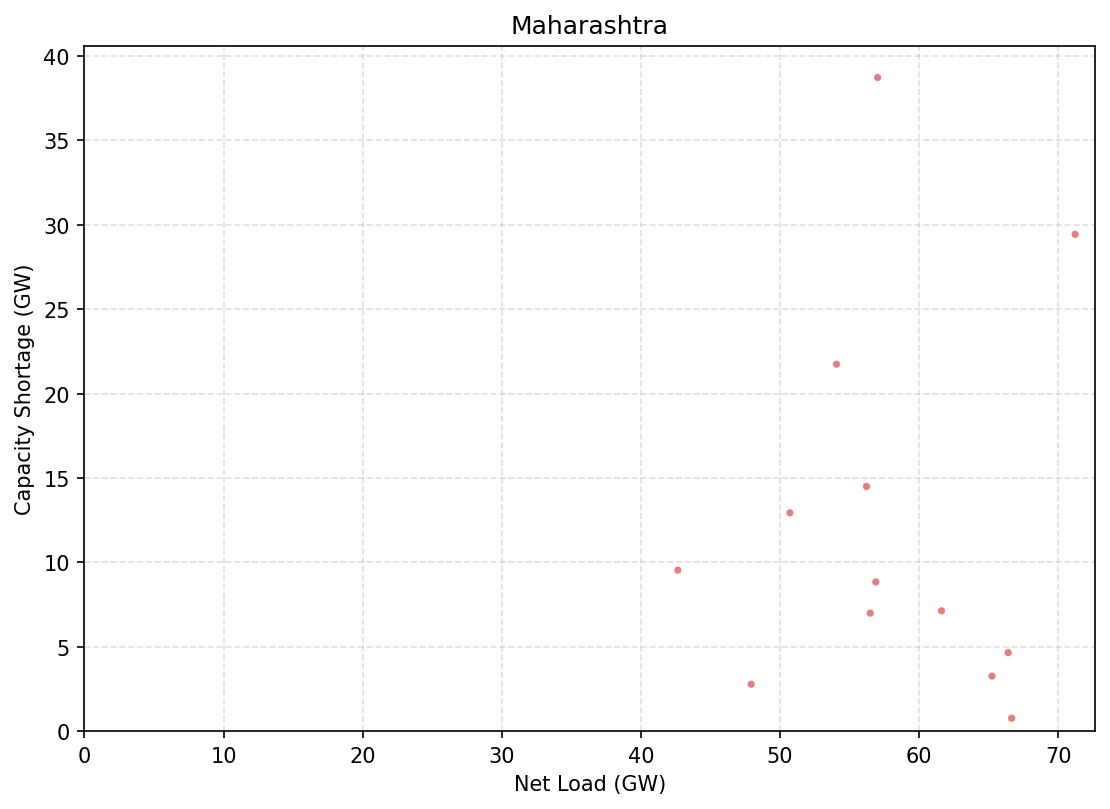

In [33]:
# Scatter plot of the Hourly Capacity Shortage (In MW) vs Hourly net Load (In MW) for the selected zone


selected_zone = "Maharashtra"   # ← change the zone if needed
only_lol      = True         # True → plot only hours with shortage (>0)
plt.rcParams.update({"font.family": "Arial", "font.size": 10})

# helper: build timestamp from YYYYMMDDHH (HH = 1..24)
def _timestamp_from_timepoint(df, tp_col='timepoint'):
    tp = df[tp_col].astype(str)
    d  = pd.to_datetime(tp.str[:8], format='%Y%m%d')
    h  = tp.str[8:].astype(int)  # 1..24
    return d + pd.to_timedelta(h - 1, unit='h')

# 1) Load table (zone slice) with timestamps
load = df_load_.copy()
if 'timestamp' not in load.columns:
    load['timestamp'] = _timestamp_from_timepoint(load)

zload = load.loc[load['load_zone'] == selected_zone,
                 ['timestamp','W','H','A','static_load','unserved_energy']].copy()
zload[['W','H','A']] = zload[['W','H','A']].astype(str)

# 2) Wind + Solar hourly power for the same zone
disp = df_dispatch_.copy()
if 'timestamp' not in disp.columns:
    disp['timestamp'] = _timestamp_from_timepoint(disp)

ws = disp[(disp['load_zone'] == selected_zone) &
          (disp['technology'].isin(['Wind','Solar']))].copy()

re_hour = (ws.groupby(['timestamp','W','H','A'], as_index=False)['power_mw']
             .sum()
             .rename(columns={'power_mw': 're_power_mw'}))

# 3) Merge and compute hourly net load (MW)
df = zload.merge(re_hour, on=['timestamp','W','H','A'], how='left')
df['re_power_mw'] = df['re_power_mw'].fillna(0.0)
df['net_load_mw'] = df['static_load'] - df['re_power_mw']   # net load definition

# 4) Convert to GW
df['net_load_gw']   = df['net_load_mw']   / 1000.0
df['shortage_gw']   = df['unserved_energy'] / 1000.0

# (optional) keep only shortage hours
if only_lol:
    df = df[df['shortage_gw'] > 0]

# 5) Scatter: Capacity Shortage (GW) vs Net Load (GW)
plt.figure(figsize=(7.5, 5.5), dpi=150)

# color: red for shortage hours, light gray otherwise
colors = np.where(df['shortage_gw'] > 0, 'tab:red', 'lightgray')

plt.scatter(df['net_load_gw'],
            df['shortage_gw'],
            s=12, c=colors, alpha=0.6, edgecolors='none')

plt.title(f"{selected_zone}")
plt.xlabel("Net Load (GW)")
plt.ylabel("Capacity Shortage (GW)")
plt.grid(True, linestyle='--', alpha=0.4)

# optional: clip negatives if not meaningful
plt.xlim(left=0)
plt.ylim(bottom=0)

plt.tight_layout()
plt.show()

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

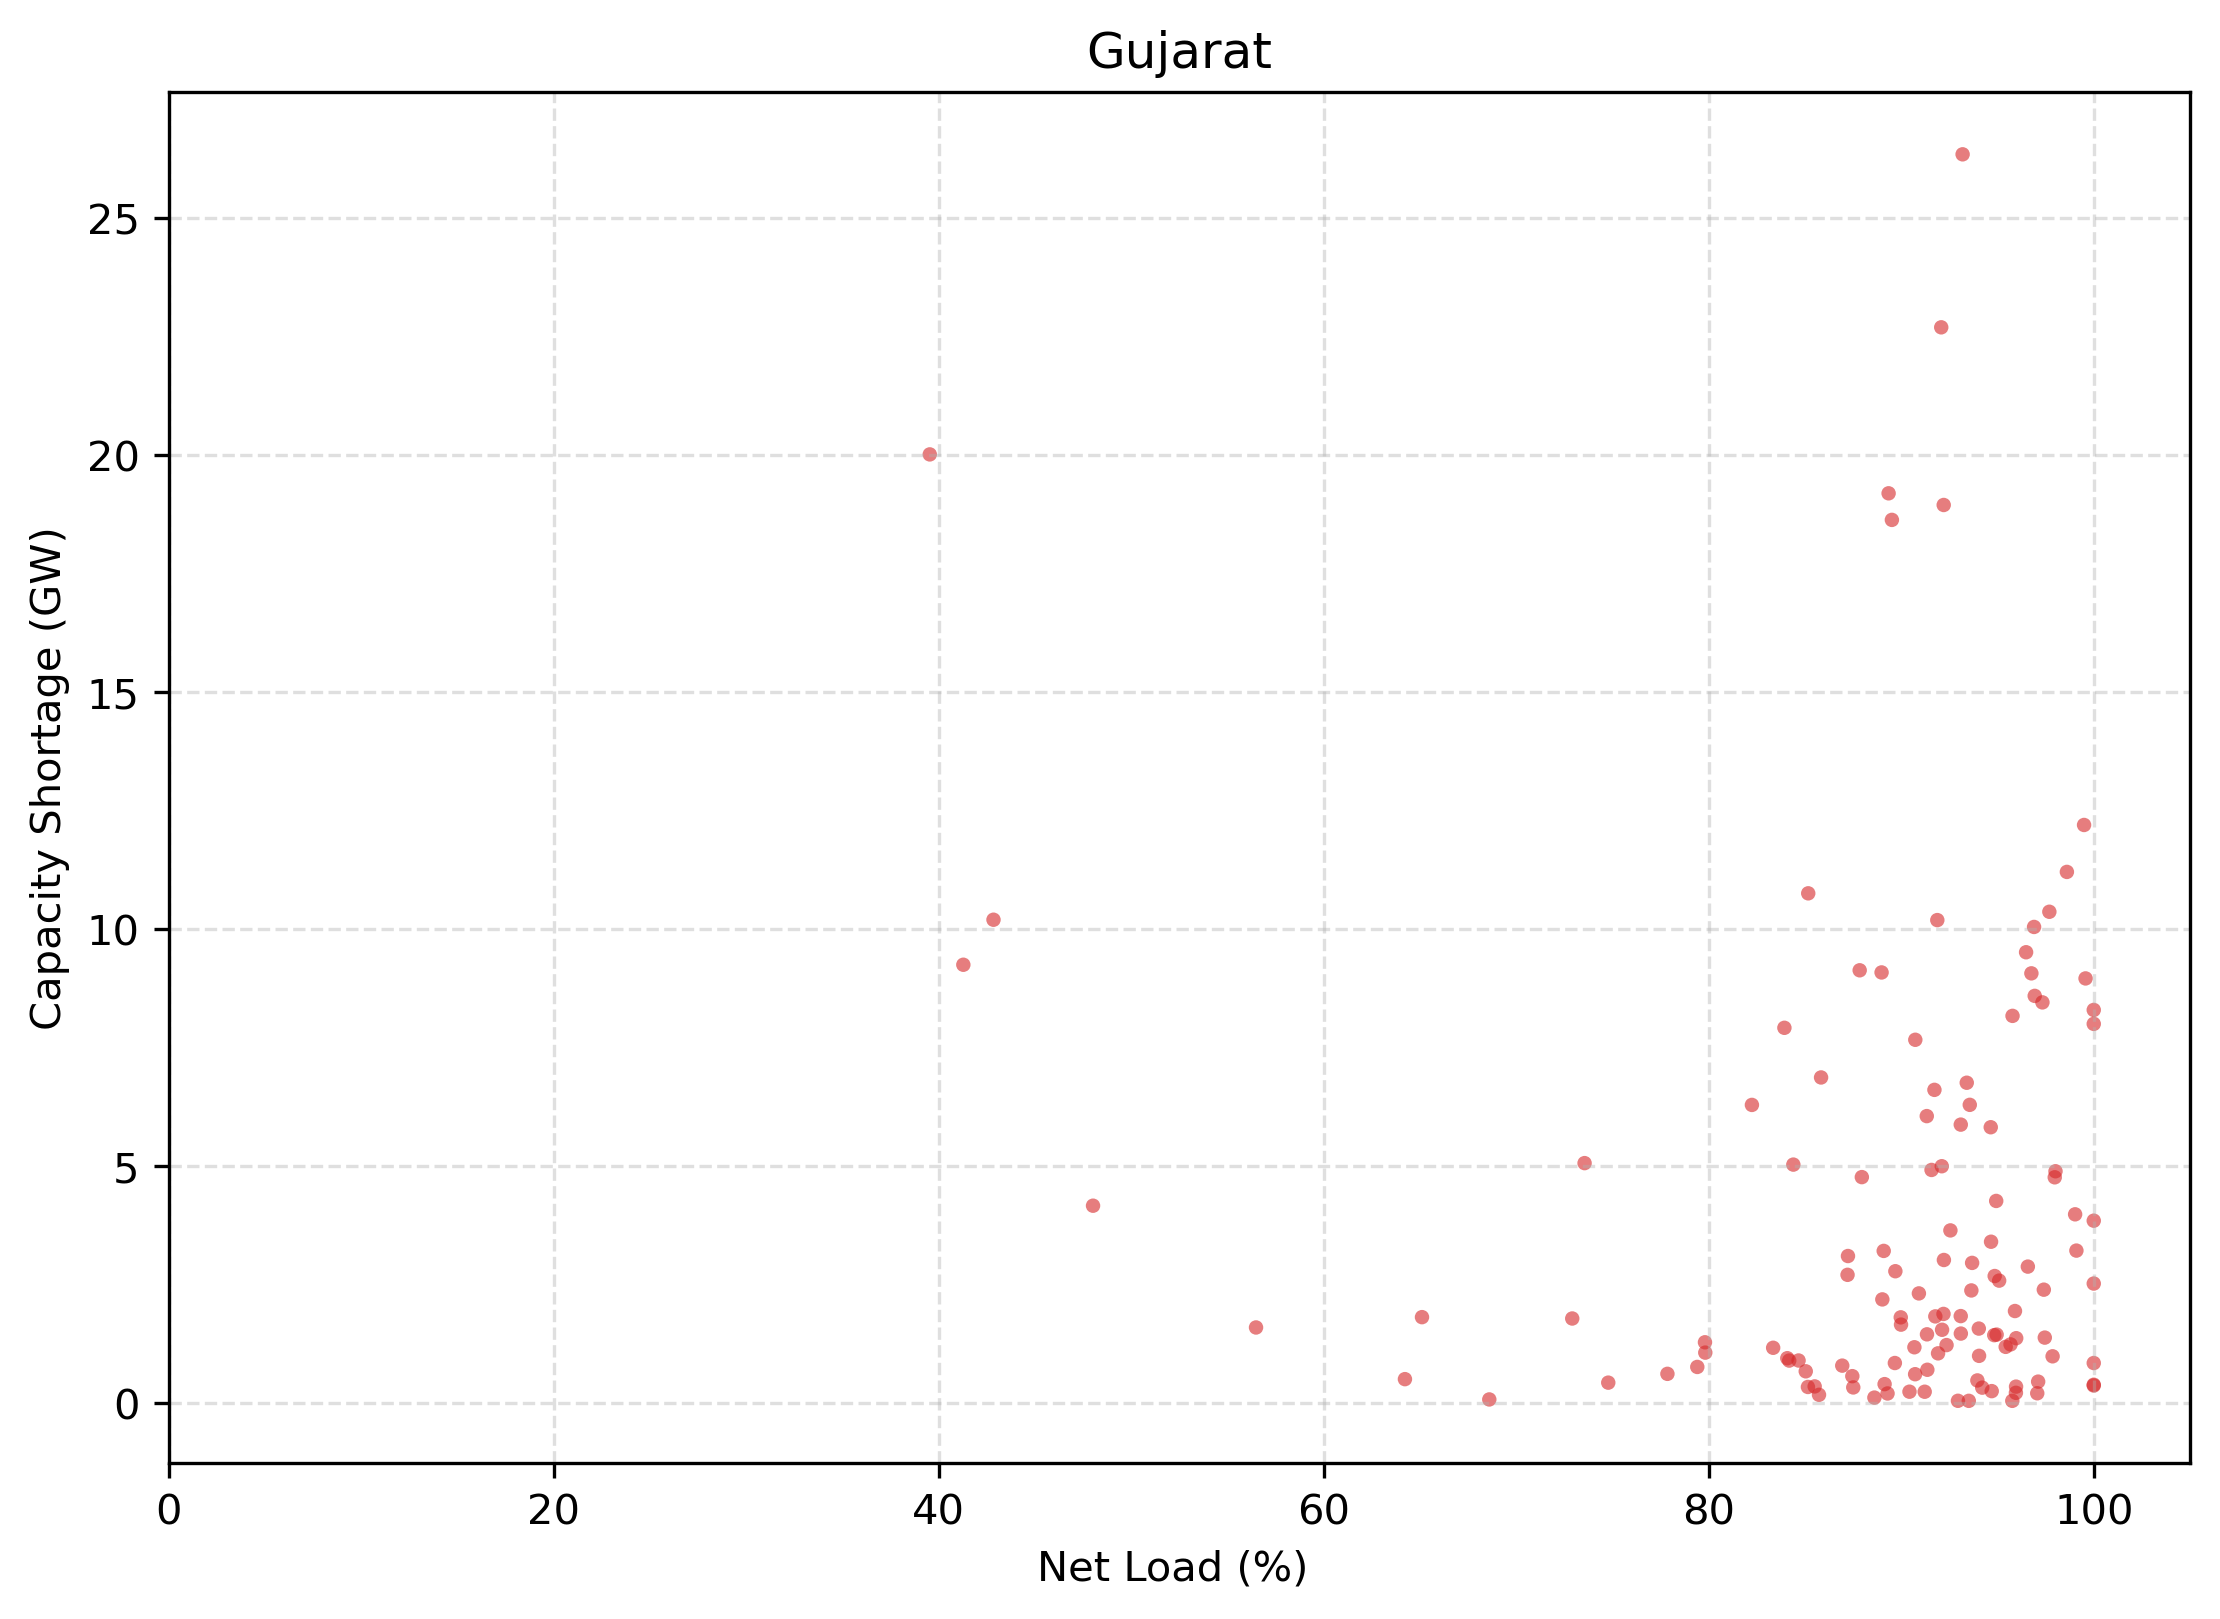

In [36]:


selected_zone = "Gujarat"   # ← change zone here
only_lol      = True         # True → plot only hours with shortage (>0)
plt.rcParams.update({"font.family": "Arial", "font.size": 10})

# helper: build timestamp from YYYYMMDDHH (HH = 1..24)
def _timestamp_from_timepoint(df, tp_col='timepoint'):
    tp = df[tp_col].astype(str)
    d  = pd.to_datetime(tp.str[:8], format='%Y%m%d')
    h  = tp.str[8:].astype(int)  # 1..24
    return d + pd.to_timedelta(h - 1, unit='h')

# 1) Load table (zone slice) with timestamps
load = df_load_.copy()
if 'timestamp' not in load.columns:
    load['timestamp'] = _timestamp_from_timepoint(load)

zload = load.loc[load['load_zone'] == selected_zone,
                 ['timestamp','W','H','A','static_load','unserved_energy']].copy()
zload[['W','H','A']] = zload[['W','H','A']].astype(str)

# 2) Wind + Solar hourly power for the same zone
disp = df_dispatch_.copy()
if 'timestamp' not in disp.columns:
    disp['timestamp'] = _timestamp_from_timepoint(disp)

ws = disp[(disp['load_zone'] == selected_zone) &
          (disp['technology'].isin(['Wind','Solar']))].copy()

re_hour = (ws.groupby(['timestamp','W','H','A'], as_index=False)['power_mw']
             .sum()
             .rename(columns={'power_mw': 're_power_mw'}))

# 3) Merge and compute hourly net load (MW)
df = zload.merge(re_hour, on=['timestamp','W','H','A'], how='left')
df['re_power_mw'] = df['re_power_mw'].fillna(0.0)
df['net_load_mw'] = df['static_load'] - df['re_power_mw']   # net load

# 4) Compute each iteration’s annual peak net load (MW), then % of peak
annual_peak = (df.groupby(['W','H','A'], as_index=False)['net_load_mw']
                 .max()
                 .rename(columns={'net_load_mw':'annual_peak_net_load_mw'}))
df = df.merge(annual_peak, on=['W','H','A'], how='left')

df['net_load_pct_peak'] = np.where(
    df['annual_peak_net_load_mw'] > 0,
    100.0 * df['net_load_mw'] / df['annual_peak_net_load_mw'],
    np.nan
)

# 5) Shortage in GW
df['shortage_gw'] = df['unserved_energy'] / 1000.0

# (optional) keep only shortage hours
if only_lol:
    df = df[df['shortage_gw'] > 0]

# 6) Scatter: Capacity Shortage (GW) vs Net Load (% of annual peak)
plt.figure(figsize=(7.5, 5.5), dpi=300)

# color: red for shortage hours, light gray otherwise
colors = np.where(df['shortage_gw'] > 0, 'tab:red', 'lightgray')

plt.scatter(df['net_load_pct_peak'],
            df['shortage_gw'],
            s=12, c=colors, alpha=0.6, edgecolors='none')

plt.title(f"{selected_zone}" )
plt.xlabel("Net Load (%) ")
plt.ylabel("Capacity Shortage (GW)")
plt.grid(True, linestyle='--', alpha=0.4)
plt.xlim(0, 105)  # small buffer beyond 100%
# plt.ylim(bottom=0)  # uncomment to clip negatives if not meaningful

plt.tight_layout()
plt.show()

# Dispatch Plots during Loss of Load days

In [35]:
# Load and processing system load timepoints
def _processing_system_load_timepoints(scenarios_):

    dfs_ = []
    for scenario, path_to_scenarios in zip(scenarios_['scenario'], scenarios_['path']):
        path_to_scenario = os.path.join(path_to_scenarios, scenario)

        for dirpath, dirnames, filenames in os.walk(path_to_scenario):
            # Processing scenarios results folder only
            if dirpath.split('/')[-1] == 'results':
                print(scenario)

                df_ = pd.read_csv(os.path.join(dirpath, 'system_load_zone_timepoint.csv'), 
                                  low_memory = False)
                
                df_ = df_[['timepoint', 
                           'load_zone', 
                           'static_load_mw',
                           'total_power_mw',
                           'net_imports_mw', 
                           'overgeneration_mw', 
                           'unserved_energy_mw']]
                
                df_ = df_.groupby(['timepoint',
                                   'load_zone']).agg({'static_load_mw': 'sum',
                                                      'total_power_mw': 'sum',
                                                      'net_imports_mw': 'sum',
                                                      'overgeneration_mw': 'sum',
                                                      'unserved_energy_mw': 'sum'}).reset_index(drop = False)
                
                df_ = df_.rename(columns = {'static_load_mw': 'static_load',
                                            'total_power_mw': 'total_power',
                                            'net_imports_mw': 'net_imports',
                                            'overgeneration_mw': 'overgeneration',
                                            'unserved_energy_mw': 'unserved_energy'})
                
                df_ = pd.melt(df_, id_vars = ['timepoint', 
                                              'load_zone'], 
                                value_vars = ['static_load', 
                                              'total_power',
                                              'net_imports',
                                              'overgeneration',
                                              'unserved_energy'], 
                                var_name   = 'technology', 
                                value_name = 'power_mw')
                
                # Add iteration descriptors to dataframe
                df_['W'] = dirpath.split('/')[-4].split('_')[-1]
                df_['H'] = dirpath.split('/')[-3].split('_')[-1]
                df_['A'] = dirpath.split('/')[-2].split('_')[-1]
                
                dfs_.append(df_)

    return pd.concat(dfs_).reset_index(drop = True)

df_load_ = _processing_system_load_timepoints(scenarios_)
print(df_load_.head())

pier_no_prm_no_ccap_2040_1
pier_no_prm_no_ccap_2040_2
pier_no_prm_no_ccap_2040_3
pier_no_prm_no_ccap_2040_4
pier_no_prm_no_ccap_2040_5
pier_no_prm_no_ccap_2040_6
pier_no_prm_no_ccap_2040_7
pier_no_prm_no_ccap_2040_8
pier_no_prm_no_ccap_2040_9
pier_no_prm_no_ccap_2040_10
pier_no_prm_no_ccap_2040_11
pier_no_prm_no_ccap_2040_12
pier_no_prm_no_ccap_2040_13
pier_no_prm_no_ccap_2040_14
pier_no_prm_no_ccap_2040_15
pier_no_prm_no_ccap_2040_16
pier_no_prm_no_ccap_2040_17


pier_no_prm_no_ccap_2040_18
    timepoint          load_zone   technology      power_mw  W  H  A
0  2040040101     Andhra_Pradesh  static_load  18479.474483  1  1  1
1  2040040101  Arunachal_Pradesh  static_load    329.816680  1  1  1
2  2040040101              Assam  static_load   4089.792284  1  1  1
3  2040040101             Bhutan  static_load      0.000000  1  1  1
4  2040040101              Bihar  static_load   9839.340580  1  1  1


In [36]:
# Load and processing projects characteristics in all iteratiions
def _processing_projects(scenarios_):

    dfs_ = []
    for scenario, path_to_scenarios in zip(scenarios_['scenario'], scenarios_['path']):
        print(path_to_scenarios)

        path_to_scenario = os.path.join(path_to_scenarios, scenario)

        for dirpath, dirnames, filenames in os.walk(path_to_scenario):
            # Processing scenarios results folder only
            if dirpath.split('/')[-1] == 'results':
                print(scenario)

                df_ = pd.read_csv(os.path.join(dirpath, 'project_period.csv'), low_memory = False)

                df_ = df_[['technology', 
                           'load_zone', 
                           'capacity_mw', 
                           'stor_energy_capacity_mwh']].rename(columns = {'stor_energy_capacity_mwh': 'energy_mwh'})

                df_ = df_.groupby(['technology',
                                   'load_zone']).agg({'capacity_mw': 'sum',
                                                      'energy_mwh': 'sum'}).reset_index(drop = False)
            
                # Add iteration descriptors to dataframe
                df_['W'] = dirpath.split('/')[-4].split('_')[-1]
                df_['H'] = dirpath.split('/')[-3].split('_')[-1]
                df_['A'] = dirpath.split('/')[-2].split('_')[-1]
                
                dfs_.append(df_)

    return pd.concat(dfs_).reset_index(drop = True)

# Group projects by technology
def _group_technology_in_project(df_, tech_labels_):

    for group in tech_labels_['group'].unique():
        df_.loc[df_['technology'].isin(tech_labels_.loc[tech_labels_['group'] == group, 'technology']), 'technology'] = group
        
    return df_.groupby(['technology', 
                        'load_zone']).agg({'capacity_mw': 'sum',
                                           'energy_mwh': 'sum'}).reset_index(drop = False)
# Load, process group projects
df_tech_ = _processing_projects(scenarios_)
df_tech_ = _group_technology_in_project(df_tech_, tech_labels_)
print(df_tech_.head())

/home/abhis/india_power/scenarios
pier_no_prm_no_ccap_2040_1
/home/abhis/india_power/scenarios
pier_no_prm_no_ccap_2040_2
/home/abhis/india_power/scenarios
pier_no_prm_no_ccap_2040_3
/home/abhis/india_power/scenarios
pier_no_prm_no_ccap_2040_4
/home/abhis/india_power/scenarios
pier_no_prm_no_ccap_2040_5
/home/abhis/india_power/scenarios
pier_no_prm_no_ccap_2040_6
/home/abhis/india_power/scenarios
pier_no_prm_no_ccap_2040_7
/home/abhis/india_power/scenarios
pier_no_prm_no_ccap_2040_8
/home/abhis/india_power/scenarios
pier_no_prm_no_ccap_2040_9
/home/abhis/india_power/scenarios
pier_no_prm_no_ccap_2040_10
/home/abhis/india_power/scenarios
pier_no_prm_no_ccap_2040_11
/home/abhis/india_power/scenarios
pier_no_prm_no_ccap_2040_12
/home/abhis/india_power/scenarios
pier_no_prm_no_ccap_2040_13
/home/abhis/india_power/scenarios
pier_no_prm_no_ccap_2040_14
/home/abhis/india_power/scenarios
pier_no_prm_no_ccap_2040_15
/home/abhis/india_power/scenarios
pier_no_prm_no_ccap_2040_16
/home/abhis/india

In [37]:
def _filter_dispatch_timepoints(df_p_, load_zones_, timepoint_0, timepoint_1, W, H, A):

    df_ = df_p_.copy()

    # Selecting timepoints, iteration, and load zone
    idx_1_ = (df_['timepoint'] >= timepoint_0) & (df_['timepoint'] <= timepoint_1) 
    idx_2_ = (df_['W'] == W) 
    idx_3_ = (df_['H'] == H) 
    idx_4_ = (df_['A'] == A)
    idx_5_ = df_['load_zone'].isin(load_zones_)

    df_ = df_[idx_1_ & idx_2_ & idx_3_ & idx_4_ & idx_5_].reset_index(drop = True)
    df_ = df_[['timepoint', 
               'technology', 
               'power_mw',
               'energy_mwh', 
               'charge_mw', 
               'discharge_mw', 
               'curtailment_mw']]

    return df_.groupby(['timepoint', 
                        'technology']).agg({'power_mw': 'sum',
                                            'energy_mwh': 'sum',
                                            'charge_mw': 'sum',
                                            'discharge_mw': 'sum',
                                            'curtailment_mw': 'sum'}).reset_index(drop = False).copy()

def _filter_load_timepoints(df_p_, load_zones_, timepoint_0, timepoint_1, W, H, A):

    df_ = df_p_.copy()

    # Selecting timepoints, iteration, and load zone
    idx_1_ = (df_['timepoint'] >= timepoint_0) & (df_['timepoint'] <= timepoint_1) 
    idx_2_ = (df_['W'] == W) 
    idx_3_ = (df_['H'] == H) 
    idx_4_ = (df_['A'] == A)
    idx_5_ = df_['load_zone'].isin(load_zones_)

    df_ = df_[idx_1_ & idx_2_ & idx_3_ & idx_4_ & idx_5_].reset_index(drop = True)
    df_ = df_[['timepoint', 
               'technology', 
               'power_mw']]

    return df_.groupby(['timepoint', 
                        'technology']).agg({'power_mw': 'sum'}).reset_index(drop = False).copy()
    

# # Load zone to be analyzed
# #load_zones_ = load_zones_p_.loc[load_zones_p_['region'] == 'Eastern', 'load_zone'].to_numpy()
# #load_zones_ = load_zones_p_.loc[[1, 2, 3], 'load_zone'].to_numpy()

# Load zone to be analyzed
load_zones_ = ['Karnataka']

# Begining and ending timepoints
timepoint_0 = 2041020701
timepoint_1 = 2041021024

# Iteration descriptors
W = '11'
H = '11'
A = '11'

# # Load zone to be analyzed
# load_zones_ = ['Odisha']

# # Begining and ending timepoints
# timepoint_0 = 2040100801
# timepoint_1 = 2040101324

# # Iteration descriptors
# WHA = '18-18-18'

# # Load zone to be analyzed
# load_zones_ = ['Karnataka']

# # Begining and ending timepoints
# timepoint_0 = 2041020101
# timepoint_1 = 2041020824

# # Iteration descriptors
# WHA = '17-17-17'

df_dispatch_p_ = _filter_dispatch_timepoints(df_dispatch_, load_zones_, timepoint_0, timepoint_1, W, H, A)
df_load_p_     = _filter_load_timepoints(df_load_, load_zones_, timepoint_0, timepoint_1, W, H, A)
print(df_dispatch_p_)
print(df_load_p_)

      timepoint technology     power_mw    energy_mwh    charge_mw  \
0    2041020701    Battery -6324.982317  15618.015036  6324.982317   
1    2041020701       Coal     0.000000      0.000000     0.000000   
2    2041020701     Diesel     0.000000      0.000000     0.000000   
3    2041020701      Hydro   468.451513      0.000000     0.000000   
4    2041020701    Nuclear   440.000000      0.000000     0.000000   
..          ...        ...          ...           ...          ...   
763  2041021024      Hydro   468.451513      0.000000     0.000000   
764  2041021024    Nuclear   660.000000      0.000000     0.000000   
765  2041021024      Other   538.236111      0.000000     0.000000   
766  2041021024      Solar     0.000000      0.000000     0.000000   
767  2041021024       Wind  1827.858260      0.000000     0.000000   

     discharge_mw  curtailment_mw  
0             0.0             0.0  
1             0.0             0.0  
2             0.0             0.0  
3             0

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

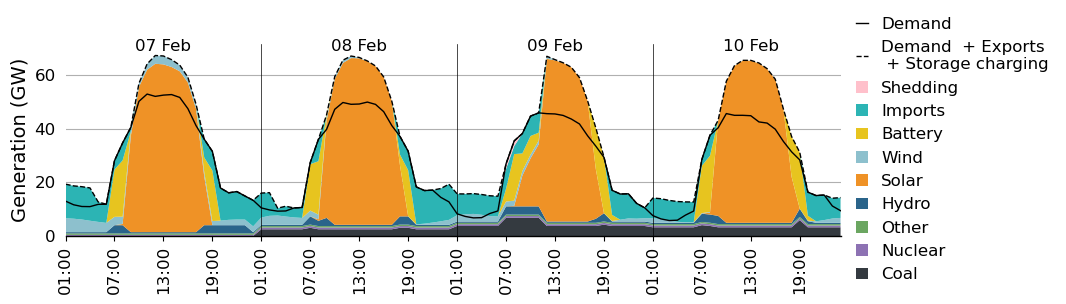

In [38]:
# Plot energy dispatch for a given day
def _plot_energy_dispatch(ax, df_1_, df_2_, tech_labels_, 
                          ylabel = r'Generation (GWh)',
                          title  = '',
                          units  = 1e3,
                          xlabel = True,
                          legend = True):
    
    def _make_dispatch_legend(ax, df_, techs_):

        for i_tech in np.sort(np.unique(techs_['order']))[::-1]:
            tech  = tech_labels_.loc[tech_labels_['order'] == i_tech, 'group'].unique()[0]
            color = tech_labels_.loc[tech_labels_['order'] == i_tech, 'group_color'].unique()[0]
            idx_  = df_['technology'] == tech
            if idx_.sum() > 0:
                if df_.loc[idx_, 'power_mw'].to_numpy().sum() != 0:
                    ax.bar(0., 0., 0., 
                           bottom = 0.,
                           color  = color,
                           label  = tech.replace('_', ' '),
                           zorder = 2,
                           ec     = 'None',
                           lw     = 0.,
                           aa     = True)

    def _processing_technology_dispatch(df_, x_, tech_labels_, colors_, dispatch_, color, tech, 
                                        dispatch = True):

        idx_ = (df_['technology'] == tech) 

        x_p_ = df_.loc[idx_, 'timepoint'].to_numpy().astype(int).astype(str)
        y_   = df_.loc[idx_, 'power_mw'].to_numpy()/units

        if dispatch:
            idx_ = y_ > 0.
        else:
            idx_ = y_ < 0.

        if idx_.sum() > 0.:
            y_p_  = np.zeros((x_.shape[0],))
            x_p_  = x_p_[idx_]
            y_    = y_[idx_]
            
            for x_p in x_p_:
                if (x_ == x_p).sum() == 1:
                    y_p_[x_ == x_p] = y_[x_p_ == x_p]

            colors_.append(color)
            dispatch_.append(y_p_)

        return dispatch_, colors_

    df_1_p_ = df_1_[['timepoint', 
                     'technology', 
                     'power_mw']].copy()
    
    df_2_p_ = df_2_[['timepoint', 
                     'technology', 
                     'power_mw']].copy()

    df_ = pd.concat([df_1_p_, df_2_p_.loc[df_2_p_['technology'] == 'net_imports']], axis = 0).reset_index(drop = True)
    df_ = pd.concat([df_, df_2_p_.loc[df_2_p_['technology'] == 'unserved_energy']], axis = 0).reset_index(drop = True)

    df_.loc[df_['technology'] == 'net_imports', 'technology'] = 'Imports'
    df_.loc[df_['technology'] == 'unserved_energy', 'technology'] = 'Shedding'

    # ---- handle timepoints ----
    x_labels_ = np.sort(df_['timepoint'].unique().astype(int)).astype(str)
    x_ = np.arange(x_labels_.shape[0])

    # Ensure exactly 10 digits for datetime parsing (YYYYMMDDHH)
    x_labels_clean = [s[:10] for s in x_labels_ if len(s) >= 10]
    dates = pd.to_datetime(x_labels_clean, format="%Y%m%d%H", errors="coerce")

    _make_dispatch_legend(ax, df_, tech_labels_)

    colors_   = []
    dispatch_ = []
    for i_tech in np.sort(np.unique(tech_labels_['order'])):
        tech  = tech_labels_.loc[tech_labels_['order'] == i_tech, 'group'].unique()[0]
        color = tech_labels_.loc[tech_labels_['order'] == i_tech, 'group_color'].unique()[0]

        dispatch_, colors_ = _processing_technology_dispatch(df_, x_labels_, tech_labels_, colors_, dispatch_, 
                                                             color, tech)
    Y_ = np.vstack(dispatch_)
    ax.stackplot(x_, Y_, 
                 colors = colors_, 
                 zorder = 10, 
                 lw     = 0.)

    colors_   = []
    dispatch_ = []
    for i_tech in np.sort(np.unique(tech_labels_['order'])):        
        tech  = tech_labels_.loc[tech_labels_['order'] == i_tech, 'group'].unique()[0]
        color = tech_labels_.loc[tech_labels_['order'] == i_tech, 'group_color'].unique()[0]
        dispatch_, colors_ = _processing_technology_dispatch(df_, x_labels_, tech_labels_, colors_, dispatch_, 
                                                             color, tech, dispatch = False)

    discharge_ = np.sum(np.vstack(dispatch_), axis = 0)
    ax.stackplot(x_, np.vstack(dispatch_), 
                 colors = colors_, 
                 zorder = 10, 
                 lw     = 0.)
    
    load_  = df_2_p_.loc[df_2_p_['technology'] == 'static_load', 'power_mw'].to_numpy()/units
    net_ = df_2_.loc[df_2_['technology'] == 'net_imports', 'power_mw'].to_numpy()/units

    ax.plot(x_, load_, color     = 'k', 
                       linestyle = '-', 
                       label     = 'Demand',
                       lw        = 1., 
                       alpha     = 1., 
                       zorder    = 11)
    
    ax.plot(x_, load_ - discharge_, 
            color     = 'k', 
            linestyle = '--', 
            label     = 'Demand  + Exports \n + Storage charging',
            lw        = 1., 
            alpha     = 1., 
            zorder    = 11)

    ax.set_ylabel(ylabel, fontsize = 14)

    ax.xaxis.set_tick_params(labelsize = 12)
    ax.yaxis.set_tick_params(labelsize = 12, left = False)
    
    # Hour labels on x-axis (every 6 hours)
    ax.set_xticks(x_[::6], [d.strftime("%H:%M") if pd.notna(d) else "" for d in dates[::6]], rotation=90)

    # Day + month labels above plot (once per day at 12:00)
    for x, d in zip(x_[12::24], dates[12::24]):
        if pd.notna(d):
            ax.text(x, np.sum(Y_, axis = 0).max()*1.05, 
                    d.strftime("%d %b"),  # e.g., "06 Feb"
                    ha='center', va='center', size = 12)
        
    for x in x_[24::24]:
        ax.axvline(x, linewidth = .5, 
                      linestyle = '-', 
                      color     = 'k', 
                      clip_on   = False, 
                      zorder    = 10)
    
    ax.axhline(0, linewidth = 1., 
                  linestyle = '-', 
                  color     = 'k', 
                  clip_on   = False, 
                  zorder    = 10)

    ax.set_xlim(x_[0], x_[-1])
    ax.set_ylim(0, )

    if legend:
        ax.legend(loc            = 'center left', 
                  bbox_to_anchor = (1., 0.45), 
                  handlelength   = .75,
                  frameon        = False,
                  prop           = {'size': 12})
        
    ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)
    ax.grid(axis = 'y')



fig = plt.figure(figsize = (10, 2.5))
_ax = plt.subplot(111)

_plot_energy_dispatch(_ax, df_dispatch_p_, df_load_p_, tech_labels_, 
                      ylabel = r'Generation (GW)',
                      title  = load_zones_[0],
                      units  = 1e3)

# plt.savefig(path_to_images + r'/dispatch-{}-{}-{}-{}.pdf'.format(load_zones_, timepoint_0, timepoint_1, W, H, A), 
#             bbox_inches = 'tight', 
#             dpi         = 600)

# plt.savefig(path_to_images + r'/dispatch-{}-{}-{}-{}.png'.format(load_zones_, timepoint_0, timepoint_1, W, H, A), 
#             bbox_inches = 'tight', 
#             dpi         = 600)


plt.show()

# Undergeneration and overgeneration heatmap

In [39]:
df_overgen = df_dispatch_.copy()
df_overgen = df_overgen[['timestamp','load_zone','curtailment_mw']]
df_overgen = df_overgen.groupby(['timestamp']).agg({'curtailment_mw': 'mean'}).reset_index(drop = False)

df_load_shedding = df_load_.copy()
df_load_shedding = df_load_shedding[['timestamp','load_zone','unserved_energy']]
df_load_shedding = df_load_shedding.groupby(['timestamp']).agg({'unserved_energy': 'sum'}).reset_index(drop = False)

df_overgen_final = pd.merge(df_overgen, df_load_shedding, on = 'timestamp', how = 'outer')
df_overgen_final['residual'] = df_overgen_final['curtailment_mw'] - df_overgen_final['unserved_energy']

KeyError: "['timestamp', 'unserved_energy'] not in index"

In [ ]:
# df_overgen_final['residual'] = df_overgen_final['curtailment_mw'] - df_overgen_final['unserved_energy']

# # Extract month and hour
# df_overgen_final['month'] = df_overgen_final['timestamp'].dt.month
# df_overgen_final['hour']  = df_overgen_final['timestamp'].dt.hour + 1  # to get 1–24

# # Build pivot table: sum of residuals by hour (rows) and month (columns)
# pivot_table = df_overgen_final.pivot_table(
#     values='residual',
#     index='hour',
#     columns='month',
#     aggfunc='sum'
# )


# # Determine max absolute residual for symmetric color scaling
# max_abs = np.abs(pivot_table.values).max()

# # Plot heatmap
# plt.figure(figsize=(12, 8))
# sns.heatmap(
#     pivot_table,
#     cmap='RdBu_r',    # reversed so negatives = red, positives = blue
#     center=0,         # zero maps to white
#     vmin=-max_abs,    # symmetric around zero
#     vmax= max_abs,
#     annot=False,
#     fmt=".1f"
# )

# # Labels and titles
# plt.xlabel('Month', fontsize=14)
# plt.ylabel('Hour of the Day', fontsize=14)
# plt.title('Heatmap of Residual (Curtailment − Unserved Energy)', fontsize=16)

# # Set month abbreviations on x-axis
# plt.xticks(
#     ticks=np.arange(0.5, 12.5),
#     labels=[calendar.month_abbr[i] for i in range(1, 13)],
#     rotation=45
# )
# plt.yticks(fontsize = 10)

# plt.tight_layout()
# plt.show()

nan nan


ValueError: cannot convert float NaN to integer

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

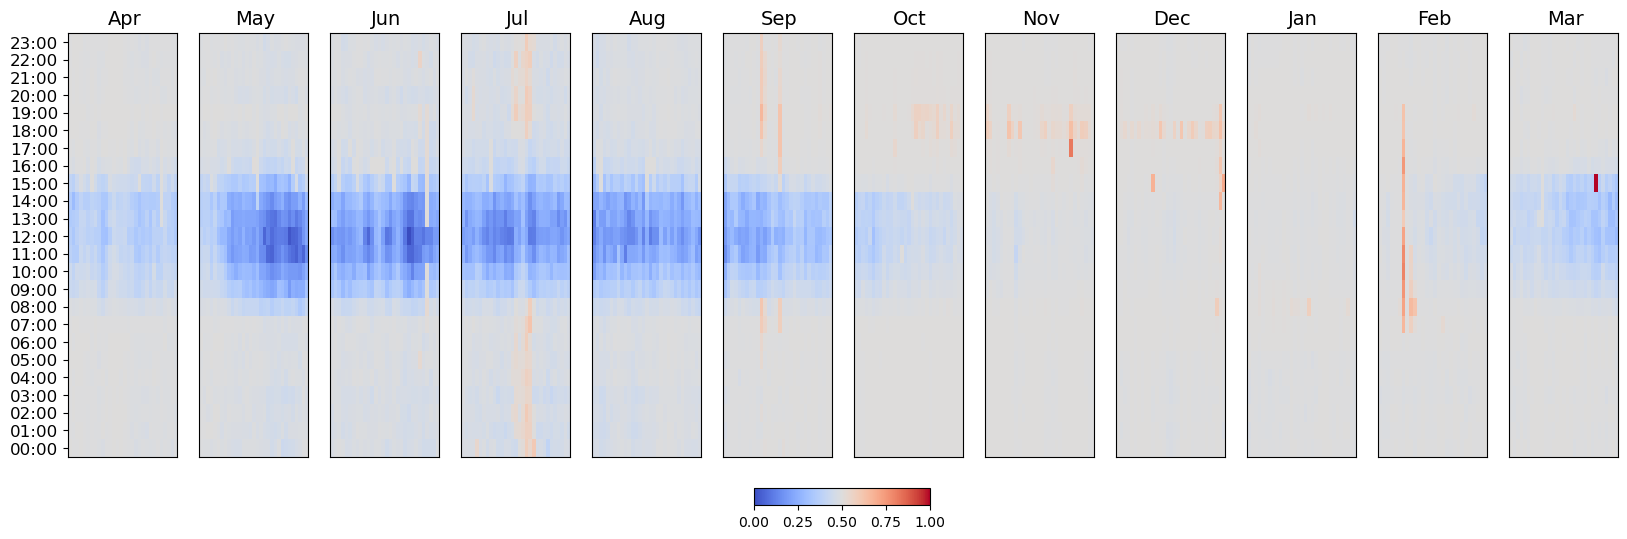

In [ ]:
def _expected_unserved_energy(ax_, EUE_, EOE_): 

    units = 1e3

    N_years = 18
    N_hours = 24
    N_days  = 365

    month_days_     = np.array([0, 30, 31, 30, 31, 31, 30, 31, 30, 31, 31, 28, 31])
    months_         = ['Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar']
    cum_month_days_ = np.cumsum(month_days_)
    
    EUE_ = np.stack([EUE_[i*N_hours:(i + 1)*N_hours] for i in range(N_days)])
    EOE_ = np.stack([EOE_[i*N_hours:(i + 1)*N_hours] for i in range(N_days)])
    EUE_ = (EOE_ - EUE_)/units
    print(EUE_.min(), EUE_.max())

    idx_under_ = EUE_ > 0
    idx_over_  = EUE_ <= 0
    norm_EUE_ = np.zeros(EUE_.shape)

    norm_EUE_[idx_under_] = EUE_[idx_under_]/EUE_[idx_under_].max()
    norm_EUE_[idx_over_]  = -EUE_[idx_over_]/EUE_[idx_over_].min()

    hours_ = np.arange(datetime(2036, 1, 1, 0), datetime(2036, 1, 2, 0), timedelta(days = 1/24)).astype(datetime)
    hours_ = pd.to_datetime(hours_).strftime('%H:%M')

    _cmap = sns.color_palette("coolwarm", as_cmap=True)

    for i in range(12):
        ax_[i].imshow(norm_EUE_[cum_month_days_[i]:cum_month_days_[i + 1], :].T, 
                      origin        = 'lower', 
                      vmin          = -1.,
                      vmax          = 1,
                      aspect        = 'auto', 
                      cmap          = _cmap,
                      interpolation = 'None')
        
        ax_[i].set_xticks([month_days_[i + 1]/2], [months_[i]], fontsize = 14)
        ax_[i].tick_params(axis = "x", length = 0)
        ax_[i].set_yticks([], [])
        ax_[i].xaxis.tick_top()

    ax_[0].set_yticks(np.linspace(0, 23, 24), hours_, fontsize = 12)

    cbar = fig.colorbar(cm.ScalarMappable(cmap = _cmap), 
                        cax = ax_[5].inset_axes([-215, -3.25, 50., 1.], transform = ax_[-1].transData), 
                        orientation = 'horizontal')

    cbar.set_ticks([0, 1], labels = [f'{-int(EUE_.max())} (GWh)', f'{-int(EUE_.min())} (GWh)'], size = 10)
    
    #cbar.ax.tick_params(length = 0)
    cbar.ax.set_title('Curtailment/Unserved Energy', rotation = 0, size = 12)
    

Shed_    = df_overgen_final['curtailment_mw'].to_numpy()
Curtail_ = df_overgen_final['unserved_energy'].to_numpy()

fig_, ax_ = plt.subplots(figsize = (20, 5.5), 
                         nrows = 1,
                         ncols = 12)

_expected_unserved_energy(ax_, Shed_, Curtail_)

plt.savefig(path_to_save_images + '/national-level_overundergen_heatmap.png', 
            bbox_inches = 'tight', 
            dpi = 600)

plt.savefig(path_to_save_images + '/national-level_overundergen_heatmap.pdf', 
            bbox_inches = 'tight', 
            dpi = 600)

plt.show() 